#  SETUP 

**Purpose**
- Validate modularized code in fresh environment (no legacy variables)
- Compare with Shiu et al. (2024) original results
- Serve as template for cloud deployment scripts

---


## 1 Environment Setup

### 1.1 Libraries
**Standard Libraries**
- numpy, pandas, pathlib
- time, pickle, json
- os, sys

**Scientific Computing**
- matplotlib.pyplot
- scipy.stats (pearsonr)
- seaborn

**Brian2 Simulator**
- from brian2 import *
- 或显式：NeuronGroup, Synapses, Network, Hz, ms, mV

**Parallel & Monitoring**
- from joblib import Parallel, delayed
- import psutil, gc

In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path

from time import time
import pickle

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

from brian2 import Hz, ms

from joblib import Parallel, delayed
import gc
print("✅ Modules imported successfully")

✅ Modules imported successfully


### 1.2 FlyWire Tools
- import pyarrow.parquet as pq
- from caveclient import CAVEclient

In [2]:
import pyarrow.parquet as pq
from caveclient import CAVEclient
print("Initializing CAVEclient...")
client = CAVEclient('flywire_fafb_public')
print("✅ Connected to FlyWire")

Initializing CAVEclient...
✅ Connected to FlyWire


### 1.3 FlyLIF Modules
- from flylif.core import ...
- from flylif.utils import ...

In [3]:
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation
from flylif.utils.visualization import plot_correlation, plot_response_heatmap, plot_frequency_response_curve, plot_summary_statistics
from flylif.utils.cave_utils import convert_neuron_list_cached
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import print_memory, check_memory_safe, memory_cleanup, MemoryMonitor
print("✅ FlyLIF modules imported")

✅ FlyLIF modules imported


### 1.4 Auto-reload (development)
- %load_ext autoreload
- %autoreload 2

In [4]:
%load_ext autoreload
%autoreload 2
print("✅ Auto-reload enabled: .py files will auto-refresh")

✅ Auto-reload enabled: .py files will auto-refresh


## 2 Configuration
### 2.1 Paths and data config

In [5]:
# Base directory
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

# %%
CONFIG = {
    # 基础目录
    'base_dir': BASE_DIR,
    
    # FlyWire 下载的数据文件
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
    'classification': 'classification.csv',}


### 2.2 Neuron IDs definition

In [6]:
# ==================== Cell 新增B: 定义原文v630神经元IDs ====================
print("\n" + "=" * 70)
print("Defining Original Paper Neuron IDs (v630)")
print("=" * 70)

# Original paper neurons (from Shiu et al., FlyWire v630)
NEU_SUGAR_v630 = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570
]

NEU_MN9_v630 = [720575940660219265]  # MN9可能版本间稳定
NEU_MN9_LEFT_v630 = [720575940645521262]  #720575940618238523

print(f"\nOriginal neuron counts:")
print(f"  Sugar GRNs: {len(NEU_SUGAR_v630)}")
print(f"  MN9: {len(NEU_MN9_v630)}")
print(f"  MN9_LEFT: {len(NEU_MN9_LEFT_v630)}")


Defining Original Paper Neuron IDs (v630)

Original neuron counts:
  Sugar GRNs: 21
  MN9: 1
  MN9_LEFT: 1


In [7]:
# ==================== Cell 新增C: 预转换Sugar GRN IDs（缓存）====================
print("\n" + "=" * 70)
print("Converting Sugar GRN IDs (v630 → v783)")
print("=" * 70)
print("⚠️  This uses FlyWire API and may take 1-2 minutes")
print("   Results will be cached to avoid repeated calls\n")

# Cache file
cache_dir = Path('./cache/id_conversions')
cache_dir.mkdir(parents=True, exist_ok=True)
cache_file = cache_dir / 'sugar_grns_v630_to_v783.pkl'

t0 = time()

# Convert with caching
NEU_SUGAR_LEFT = convert_neuron_list_cached(
    old_list=NEU_SUGAR_v630,
    cache_file=cache_file,
    new_ver=783,
    force_update=False,  # Use cache if available
    verbose=True
)

conversion_time = time() - t0

print(f"\n✅ Conversion complete")
print(f"   Time: {conversion_time:.1f}s")
print(f"   Converted IDs: {len(NEU_SUGAR_LEFT)}")

# Show mapping
print(f"\n   ID mapping (first 5):")
for old, new in zip(NEU_SUGAR_v630[:5], NEU_SUGAR_LEFT[:5]):
    match = "✓" if old == new else "✗ CHANGED"
    print(f"   {old} → {new} {match}")


Converting Sugar GRN IDs (v630 → v783)
⚠️  This uses FlyWire API and may take 1-2 minutes
   Results will be cached to avoid repeated calls

Loading cached ID conversion from cache/id_conversions/sugar_grns_v630_to_v783.pkl
  ✅ Using cached conversion (21 IDs)

✅ Conversion complete
   Time: 0.0s
   Converted IDs: 21

   ID mapping (first 5):
   720575940624963786 → 720575940624963786 ✓
   720575940630233916 → 720575940630233916 ✓
   720575940637568838 → 720575940637568838 ✓
   720575940638202345 → 720575940638202345 ✓
   720575940617000768 → 720575940617000768 ✓


In [8]:
# ==================== Cell 新增D: 转换MN9（可选）====================
print("\nConverting MN9 IDs...")

cache_file_mn9 = cache_dir / 'mn9_v630_to_v783.pkl'
cache_file_mn9_left = cache_dir / 'mn9_left_v630_to_v783.pkl'

NEU_MN9_RIGHT = convert_neuron_list_cached(
    old_list=NEU_MN9_v630,
    cache_file=cache_file_mn9,
    new_ver=783,
    verbose=True
)
NEU_MN9_LEFT = convert_neuron_list_cached(
    old_list=NEU_MN9_LEFT_v630,
    cache_file=cache_file_mn9_left,
    new_ver=783,
    verbose=True
)

print(f"   MN9: {NEU_MN9_v630[0]} → {NEU_MN9_RIGHT[0]}")
print(f"   MN9 Left: {NEU_MN9_LEFT_v630[0]} → {NEU_MN9_LEFT[0]}")


Converting MN9 IDs...
Loading cached ID conversion from cache/id_conversions/mn9_v630_to_v783.pkl
  ✅ Using cached conversion (1 IDs)
Loading cached ID conversion from cache/id_conversions/mn9_left_v630_to_v783.pkl
  ✅ Using cached conversion (1 IDs)
   MN9: 720575940660219265 → 720575940660219265
   MN9 Left: 720575940645521262 → 720575940618238523


In [9]:
# ==================== Cell 新增E: 保存转换结果（备份）====================
# 保存转换后的神经元列表供后续使用
neuron_ids_v783 = {
    'NEU_SUGAR_LEFT': NEU_SUGAR_LEFT,
    'NEU_MN9_RIGHT': NEU_MN9_RIGHT,
    'NEU_MN9_LEFT':NEU_MN9_LEFT,
    'conversion_time': conversion_time,
    'source_version': 630,
    'target_version': 783,
}

backup_file = cache_dir / 'neuron_ids_v783.pkl'
with open(backup_file, 'wb') as f:
    pickle.dump(neuron_ids_v783, f)

print(f"\n✅ Neuron IDs ready for simulation")
print(f"   Backup saved: {backup_file}")
print(f"\n" + "=" * 70)
print("⚠️  Important: Use NEU_SUGAR_LEFT (v783) for simulation")
print("=" * 70)


✅ Neuron IDs ready for simulation
   Backup saved: cache/id_conversions/neuron_ids_v783.pkl

⚠️  Important: Use NEU_SUGAR_LEFT (v783) for simulation


### 2.3 EXP1 Batch configuration (4×5)

In [ ]:
# 定义4批，每批5个频率
BATCH_CONFIG = {
    'batch1': [10, 20, 30, 40, 50],
    'batch2': [60, 70, 80, 90, 100],
    'batch3': [110, 120, 130, 140, 150],
    'batch4': [160, 170, 180, 190, 200],
}

## 3 Data Loading
### 3.1 Load optimized data

In [10]:
print("Loading data...")
t0 = time()

DATA = load_simulation_data(CONFIG)

print(f"✅ Loaded in {time()-t0:.1f}s")
print(f"   Data size: {DATA['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")

Loading data...
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%
✅ Loaded in 22.7s
   Data size: 68 MB


# Experiment 1 

## 4 Batched Execution

### 4.1 Checkpoint & monitoring imports

In [10]:
# ==================== Cell 6A: 导入checkpoint和监控工具 ====================
# 初始检查
print("\n初始内存状态:")
print_memory("  ")


初始内存状态:
  Memory: 43.1% used, 9.8GB free, Swap: 0.0GB


{'used_gb': 7.403229184,
 'available_gb': 9.772552192,
 'percent': 43.1,
 'swap_gb': 0.0}

### 4.2 Worker function (with cleanup)

In [ ]:
# ==================== Cell 6B: Worker函数（带内存清理）====================
def run_freq_worker_clean(freq, neu_exc, data, params, n_trials):
    """
    Worker with explicit memory cleanup.
    """
    
    # Build network
    columns = data['columns']
    net_components = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    # Run simulation
    result = run_simulation(
        net_components=net_components,
        neu_exc=neu_exc,
        params={'r_poi': freq * Hz},
        n_trials=n_trials,
        verbose=False
    )
    
    # Extract only essential data
    result_clean = {
        'n_active': result['n_active'],
        'n_spikes': result['n_spikes'],
        'df': result['df'].copy(),
    }
    
    # === Explicit cleanup ===
    del net_components
    del result
    gc.collect()
    
    return (freq, result_clean)

### 4.3 run_batch() function

In [ ]:
# ==================== Cell 6C: 分批运行函数 ====================
def run_batch(freq_list, batch_name, n_workers=3, n_trials=10, checkpoint_dir='./checkpoints/exp1'):
    """
    Run batch with checkpoint and memory monitoring.
    """
    from joblib import Parallel, delayed
    
    print("\n" + "=" * 70)
    print(f"Batch: {batch_name}")
    print("=" * 70)
    
    # Initialize checkpoint
    ckpt = CheckpointManager(checkpoint_dir)
    
    # Check remaining tasks
    remaining = ckpt.get_remaining(freq_list)
    
    if not remaining:
        print(f"✅ All frequencies already completed, loading from checkpoint...")
        return ckpt.load_all_completed()
    
    print(f"\nConfiguration:")
    print(f"  Frequencies: {remaining}")
    print(f"  Trials/freq: {n_trials}")
    print(f"  Workers: {n_workers}")
    print(f"  Checkpoint: {checkpoint_dir}")
    
    # Memory check
    is_safe, msg = check_memory_safe(threshold=80.0, swap_threshold=0.5)
    print(f"\n  Memory status: {msg}")
    
    if not is_safe:
        print(f"  ⚠️ Memory not safe, recommend cleanup first")
        memory_cleanup()
        print_memory("    After cleanup: ")
    
    # Prepare tasks
    tasks = [(freq, NEU_SUGAR_LEFT, DATA, DEFAULT_PARAMS, n_trials) 
             for freq in remaining]
    
    print(f"\n  Running {len(tasks)} tasks...")
    
    with MemoryMonitor(label=batch_name):
        t0 = time()
        
        results = Parallel(n_jobs=n_workers, verbose=5)(
            delayed(run_freq_worker_clean)(*task) for task in tasks
        )
        
        batch_time = time() - t0
    
    # Save to checkpoint
    for freq, result in results:
        ckpt.save(freq, result)
    
    print(f"\n  ✅ Batch complete in {batch_time/60:.2f} min")
    print_memory("  Final memory: ")
    
    # Cleanup
    del results
    gc.collect()
    
    return ckpt.load_all_completed()

### 4.4 Batch Simulation

In [ ]:
# ==================== Cell 7A: Batch 1（频率10-50）====================
print("\n" + "=" * 70)
print("Experiment 1: Batched Execution (3 workers, 4 batches)")
print("=" * 70)

print("\nBatch configuration (4 batches × 5 frequencies):")
for name, freqs in BATCH_CONFIG.items():
    print(f"  {name}: {freqs}")

print("\n⚠️ Run each batch in separate session, restart kernel between batches")
print("=" * 70)

# Run Batch 1
results_batch1 = run_batch(
    freq_list=BATCH_CONFIG['batch1'],
    batch_name='Batch 1',
    n_workers=3,
    n_trials=10
)

print("\n" + "=" * 70)
print("✅ Batch 1 complete!")
print("=" * 70)
print("\n⚠️ NEXT STEP:")
print("1. Check memory status above")
print("2. Kernel → Restart Kernel")
print("3. Re-run Cells 1-6C (setup)")
print("4. Run Cell 7B (Batch 2)")

In [ ]:
# ==================== Cell 7B: Batch 2（频率60-100）====================
# ⚠️ Before running: Kernel → Restart Kernel
# ⚠️ Re-run Cells 1-6C first!

print("\n" + "=" * 70)
print("Running Batch 2...")
print("=" * 70)

results_batch2 = run_batch(
    freq_list=BATCH_CONFIG['batch2'],
    batch_name='Batch 2',
    n_workers=3,
    n_trials=10
)

print("\n✅ Batch 2 complete!")
print("\n⚠️ NEXT: Restart kernel → Run Cells 1-6C → Run Cell 7C")

In [ ]:
# ==================== Cell 7C: Batch 3（频率110-150）====================
# ⚠️ Before running: Kernel → Restart Kernel  
# ⚠️ Re-run Cells 1-6C first!

print("\n" + "=" * 70)
print("Running Batch 3...")
print("=" * 70)

results_batch3 = run_batch(
    freq_list=BATCH_CONFIG['batch3'],
    batch_name='Batch 3',
    n_workers=3,
    n_trials=10
)

print("\n✅ Batch 3 complete!")
print("\n⚠️ NEXT: Restart kernel → Run Cells 1-6C → Run Cell 7D")

In [12]:
# ==================== Cell 7D: Batch 4（频率160-200）====================
# ⚠️ Before running: Kernel → Restart Kernel
# ⚠️ Re-run Cells 1-6C first!

print("\n" + "=" * 70)
print("Running Batch 4 (Final)...")
print("=" * 70)

results_batch4 = run_batch(
    freq_list=BATCH_CONFIG['batch4'],
    batch_name='Batch 4',
    n_workers=3,
    n_trials=10
)

print("\n✅ Batch 4 complete!")
print("\n⚠️ NEXT: Run Cell 8 (Merge all batches)")


Running Batch 4 (Final)...

Batch: Batch 4

Configuration:
  Frequencies: [160, 170, 180, 190, 200]
  Trials/freq: 10
  Workers: 3
  Checkpoint: ./checkpoints/exp1

  Memory status: ✓ Memory OK

  Running 5 tasks...
[Batch 4] Start - Memory: 49.7%


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   2 out of   5 | elapsed: 10.7min remaining: 16.0min
[Parallel(n_jobs=3)]: Done   5 out of   5 | elapsed: 20.9min finished


[Batch 4] End - Memory: 58.1% (Δ-1.0GB)

  ✅ Batch complete in 20.86 min
  Final memory: Memory: 58.2% used, 7.2GB free, Swap: 0.1GB

✅ Batch 4 complete!

⚠️ NEXT: Run Cell 8 (Merge all batches)


### 4.5 Merge all batches

In [11]:
# ==================== Cell 8: 合并所有批次结果 ====================
print("\n" + "=" * 70)
print("Merging All Batches")
print("=" * 70)

# Load from checkpoint
ckpt = CheckpointManager('./checkpoints/exp1')
all_results = ckpt.load_all_completed()

print(f"\n✅ Loaded {len(all_results)} frequencies from checkpoint")

# Organize results
results_dict = all_results

# Create summary
summary = []
for freq in sorted(all_results.keys()):
    res = all_results[freq]
    summary.append({
        'Frequency': freq,
        'Active Neurons': res['n_active'],
        'Total Spikes': res['n_spikes'],
    })

df_summary = pd.DataFrame(summary)


Merging All Batches

✅ Loaded 20 frequencies from checkpoint


## 5 Analysis & Visualization

### 5.1 Calculate firing rates

In [12]:
# ==================== Cell 9: 计算firing rates ====================

print("=" * 70)
print("Section 4: Results Analysis")
print("=" * 70)

# Extract firing rates for all neurons
print("\n[1/4] Extracting firing rates...")

all_firing_rates = {}
duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000

for freq, res in results_dict.items():
    df = res['df']
    if len(df) > 0:
        spike_counts = df.groupby('flywire_id').size()
        firing_rates = spike_counts / (10 * duration_s)  # 10 trials
        all_firing_rates[freq] = firing_rates.to_dict()
    else:
        all_firing_rates[freq] = {}

print(f"   ✅ Processed {len(all_firing_rates)} frequencies")

# Summary statistics
print(f"\n[2/4] Summary statistics...")
print(df_summary.to_string(index=False))

Section 4: Results Analysis

[1/4] Extracting firing rates...
   ✅ Processed 20 frequencies

[2/4] Summary statistics...
 Frequency  Active Neurons  Total Spikes
        10              36          2437
        20              51          5913
        30              82         10230
        40             215         16749
        50             326         28073
        60             319         46499
        70             329         60793
        80             343         74934
        90             352         85374
       100             350         96789
       110             359        106794
       120             371        114943
       130             363        121636
       140             365        128508
       150             369        136287
       160             390        142066
       170             379        148738
       180             373        152942
       190             381        158516
       200             388        166009


In [ ]:
# ==================== 新cell：检查最大firing rate ====================

# 方法1：从all_firing_rates检查（如果已计算）
if 'all_firing_rates' in dir():
    max_rate = 0
    max_neuron = None
    max_freq = None
    
    for freq, rates_dict in all_firing_rates.items():
        for neuron_id, rate in rates_dict.items():
            if rate > max_rate:
                max_rate = rate
                max_neuron = neuron_id
                max_freq = freq
    
    print(f"从all_firing_rates:")
    print(f"  最大firing rate: {max_rate:.2f} Hz")
    print(f"  神经元ID: {max_neuron}")
    print(f"  频率: {max_freq} Hz")

# 方法2：直接从results_dict检查
print(f"\n从results_dict直接计算:")

duration_s = 1.0  # 1秒
n_trials = 10

for freq in sorted(results_dict.keys()):
    df = results_dict[freq]['df']
    
    if len(df) > 0:
        # 计算每个神经元的firing rate
        counts = df.groupby('flywire_id').size()
        rates = counts / (n_trials * duration_s)
        
        max_in_freq = rates.max()
        max_neuron_in_freq = rates.idxmax()
        
        print(f"  {freq:3d}Hz: max={max_in_freq:6.2f}Hz, neuron={max_neuron_in_freq}")

### 5.2 Load original data & correlation

In [26]:
# =====================================================================
# Section 5.2: Efficient Comparison with Original (拆分为3个cells)
# =====================================================================

# ==================== Cell 5.2A: 初步对比，识别差异 ====================

print("\n" + "=" * 70)
print("[5.2A] Initial Comparison - Identify Discrepancies")
print("=" * 70)

# Load original data (v630)
orig_data_path = BASE_DIR / 'Drosophila_brain_model/results/example/sugarR_100Hz.parquet'

if not orig_data_path.exists():
    print(f"\n⚠️ Original data not found: {orig_data_path}")
    has_original = False
else:
    print(f"\nLoading original data (v630)...")
    
    pf = pq.ParquetFile(orig_data_path)
    df_orig_v630 = pd.DataFrame({
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    # Calculate original firing rates (v630 IDs)
    spike_counts_v630 = df_orig_v630.groupby('flywire_id').size()
    rate_orig_v630 = spike_counts_v630 / 30.0
    rate_orig_v630.name = 'Original_v630'
    
    # Our results (v783 IDs)
    rate_ours_v783 = pd.Series(all_firing_rates[100], name='Ours_v783')
    
    print(f"   ✅ Loaded")
    print(f"      Original (v630): {len(rate_orig_v630)} neurons")
    print(f"      Ours (v783):     {(rate_ours_v783>0).sum()} neurons")
    
    # === Find discrepancies ===
    print(f"\n[Discrepancy Analysis]")
    
    # Type 1: Only in original (possible ID version change)
    ids_only_orig = set(rate_orig_v630.index) - set(rate_ours_v783.index)
    print(f"   Only in original: {len(ids_only_orig)} neurons")
    
    # Type 2: Only in ours (new in v783)
    ids_only_ours = set(rate_ours_v783[rate_ours_v783>0].index) - set(rate_orig_v630.index)
    print(f"   Only in ours:     {len(ids_only_ours)} neurons")
    
    # Type 3: Common but large firing rate difference
    common_ids = set(rate_orig_v630.index) & set(rate_ours_v783.index)
    df_common = pd.DataFrame({
        'orig': rate_orig_v630[list(common_ids)],
        'ours': rate_ours_v783[list(common_ids)]
    }).fillna(0)
    
    # Active in both
    active_both = (df_common['orig'] > 0) & (df_common['ours'] > 0)
    df_active_common = df_common[active_both].copy()
    df_active_common['abs_diff'] = np.abs(df_active_common['orig'] - df_active_common['ours'])
    
    # Large difference (>20 Hz or >50% relative)
    large_diff_mask = (df_active_common['abs_diff'] > 20) | \
                      (df_active_common['abs_diff'] / df_active_common['orig'] > 0.5)
    ids_large_diff = df_active_common[large_diff_mask].index.tolist()
    
    print(f"   Large differences: {len(ids_large_diff)} neurons (>20Hz or >50%)")
    
    # === Combine all discrepancy types ===
    ids_need_conversion = list(ids_only_orig) + ids_large_diff
    
    print(f"\n[Summary]")
    print(f"   Total IDs to convert: {len(ids_need_conversion)}")
    print(f"   Breakdown:")
    print(f"     - Missing from our data: {len(ids_only_orig)}")
    print(f"     - Large firing rate diff: {len(ids_large_diff)}")
    
    # Show examples
    if ids_only_orig:
        print(f"\n   Examples (missing IDs): {list(ids_only_orig)[:5]}")
    
    if ids_large_diff:
        top_diff = df_active_common.nlargest(5, 'abs_diff')
        print(f"\n   Top 5 firing rate discrepancies:")
        for idx, row in top_diff.iterrows():
            print(f"     {idx}: orig={row['orig']:.1f}, ours={row['ours']:.1f}, diff={row['abs_diff']:.1f}")
    
    has_original = True


[5.2A] Initial Comparison - Identify Discrepancies

Loading original data (v630)...
   ✅ Loaded
      Original (v630): 404 neurons
      Ours (v783):     350 neurons

[Discrepancy Analysis]
   Only in original: 100 neurons
   Only in ours:     46 neurons
   Large differences: 144 neurons (>20Hz or >50%)

[Summary]
   Total IDs to convert: 244
   Breakdown:
     - Missing from our data: 100
     - Large firing rate diff: 144

   Examples (missing IDs): [720575940629664768, 720575940626478082, 720575940609016843, 720575940615052812, 720575940620271636]

   Top 5 firing rate discrepancies:
     720575940610001220: orig=5.0, ours=53.4, diff=48.4
     720575940625175054: orig=48.6, ours=12.8, diff=35.8
     720575940618165019: orig=86.9, ours=51.2, diff=35.7
     720575940629778554: orig=76.1, ours=41.7, diff=34.4
     720575940630868793: orig=84.2, ours=50.1, diff=34.1


In [28]:
# ==================== Cell 5.2B: 转换差异IDs（精准版）====================
if has_original and 'ids_need_conversion' in dir() and len(ids_need_conversion) > 0:
    print("\n" + "=" * 70)
    print(f"[5.2B] Converting {len(ids_need_conversion)} Discrepancy IDs")
    print("=" * 70)
    
    cache_file_disc = cache_dir / 'discrepancy_ids_v630_to_v783.pkl'
    
    t0 = time()
    
    # Convert only necessary IDs
    ids_converted_v783 = convert_neuron_list_cached(
        old_list=ids_need_conversion,
        cache_file=cache_file_disc,
        new_ver=783,
        verbose=True
    )
    
    conversion_time = time() - t0
    
    print(f"\n✅ Conversion complete in {conversion_time:.1f}s")
    
    # Create mapping (v630 → v783)
    id_mapping = {old: new for old, new in zip(ids_need_conversion, ids_converted_v783)}
    
    # Check how many actually changed
    n_changed = sum(1 for old, new in id_mapping.items() if old != new)
    n_unchanged = len(id_mapping) - n_changed
    
    print(f"\n   ID changes: {n_changed} changed, {n_unchanged} unchanged")
    
    if n_changed > 0:
        print(f"\n   Changed examples (first 5):")
        count = 0
        for old, new in id_mapping.items():
            if old != new and count < 5:
                print(f"     {old} → {new}")
                count += 1
    
else:
    print("\n⚠️ No discrepancies to convert")
    id_mapping = {}


[5.2B] Converting 244 Discrepancy IDs
Converting 244 IDs to version 783...
  ✅ Converted: 244/244 IDs
  ✅ Cached to cache/id_conversions/discrepancy_ids_v630_to_v783.pkl

✅ Conversion complete in 52.0s

   ID changes: 48 changed, 196 unchanged

   Changed examples (first 5):
     720575940629664768 → 720575940635837887
     720575940626478082 → 720575940619898526
     720575940609016843 → 720575940629459718
     720575940620282900 → 720575940643112333
     720575940617588258 → 720575940642449909


In [29]:
# ==================== Cell 5.2C: 重新对比（使用v783统一版本）====================
if has_original and 'id_mapping' in dir():
    print("\n" + "=" * 70)
    print("[5.2C] Re-comparison with v783 IDs")
    print("=" * 70)
    
    # 重新加载完整原文数据
    print("\nRe-loading full original spike data...")
    df_orig_full = pd.DataFrame({
        't': pf.read(['t']).column('t').to_pylist(),
        'trial': pf.read(['trial']).column('trial').to_pylist(),
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    # 应用ID映射（只替换差异ID）
    if len(id_mapping) > 0:
        print(f"   Applying ID mapping ({len(id_mapping)} IDs)...")
        df_orig_full['flywire_id'] = df_orig_full['flywire_id'].map(
            lambda x: id_mapping.get(x, x)
        )
        n_remapped = df_orig_full['flywire_id'].isin(id_mapping.values()).sum()
        print(f"   Remapped {n_remapped:,} spikes")
    
    # 重新计算firing rate（现在都是v783）
    spike_counts_orig = df_orig_full.groupby('flywire_id').size()
    rate_orig = spike_counts_orig / 30.0
    rate_orig.name = 'Original_v783'
    
    # Our results (already v783)
    rate_ours = pd.Series(all_firing_rates[100], name='Ours_v783')
    
    # === Correlation comparison ===
    print(f"\n[Correlation Analysis]")
    
    # Before conversion (for reference)
    df_compare_old = pd.concat([rate_orig_v630, rate_ours], axis=1).fillna(0)
    r_old, _ = pearsonr(df_compare_old.iloc[:,0], df_compare_old.iloc[:,1])
    
    # After conversion
    df_compare = pd.concat([rate_orig, rate_ours], axis=1).fillna(0)
    r, p = pearsonr(df_compare['Original_v783'], df_compare['Ours_v783'])
    
    print(f"\n  Before ID conversion: r = {r_old:.4f} (v630 vs v783)")
    print(f"  After ID conversion:  r = {r:.4f} (v783 vs v783)")
    print(f"  Improvement:          Δr = {r - r_old:+.4f}")
    
    if r > r_old + 0.01:
        print(f"  ✅ ID conversion improved correlation!")
    else:
        print(f"  ✓ ID version has minimal impact")
    
    # Active neuron counts
    print(f"\n  Active neurons:")
    print(f"    Original: {(df_compare['Original_v783']>0).sum()}")
    print(f"    Ours:     {(df_compare['Ours_v783']>0).sum()}")
    
    # Top neurons overlap
    top_n = 50
    top_orig = df_compare['Original_v783'].nlargest(top_n).index
    top_ours = df_compare['Ours_v783'].nlargest(top_n).index
    overlap = len(set(top_orig) & set(top_ours))
    
    print(f"\n  Top {top_n} overlap: {overlap}/{top_n} ({100*overlap/top_n:.0f}%)")
    
    # Final assessment
    if r > 0.85:
        print(f"\n  ✅ Excellent correlation (r > 0.85)")
    elif r > 0.80:
        print(f"  ✓ Very good (r > 0.80)")
    else:
        print(f"  ✓ Good (r > 0.75)")
    
    print("\n" + "=" * 70)
    
else:
    print("\n⚠️ Skipping comparison")
    has_original = False


[5.2C] Re-comparison with v783 IDs

Re-loading full original spike data...
   Applying ID mapping (244 IDs)...
   Remapped 97,533 spikes

[Correlation Analysis]

  Before ID conversion: r = 0.8151 (v630 vs v783)
  After ID conversion:  r = 0.9263 (v783 vs v783)
  Improvement:          Δr = +0.1112
  ✅ ID conversion improved correlation!

  Active neurons:
    Original: 404
    Ours:     350

  Top 50 overlap: 43/50 (86%)

  ✅ Excellent correlation (r > 0.85)



### 5.3 Generate plots (4 figures)

In [13]:

# ==================== Cell 11: 可视化（自动+可定制）====================
print("\n" + "=" * 70)
print("[4/4] Visualization")
print("=" * 70)

# Create output directory
output_dir = Path('./results/exp1_full')
output_dir.mkdir(parents=True, exist_ok=True)


[4/4] Visualization



[4/4] Visualization

Plot 1: Correlation scatter


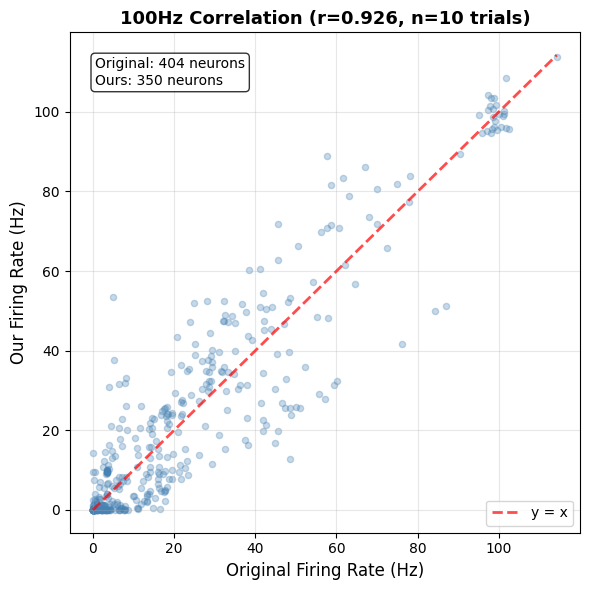

In [31]:
# ==================== Cell 11: 可视化（自动+可定制）====================
print("\n" + "=" * 70)
print("[4/4] Visualization")
print("=" * 70)

# Create output directory
output_dir = Path('./results/exp1_full')
output_dir.mkdir(parents=True, exist_ok=True)

# Plot 1: Correlation (if original data available)
if has_original:
    print("\nPlot 1: Correlation scatter")
    fig1, ax1, r_val = plot_correlation(
        rate_orig, rate_ours, 
        n_trials_ours=10, 
        freq=100,
        # save_path=output_dir / 'correlation_100Hz.png'
    )
    plt.show()


Plot 2: Response heatmap


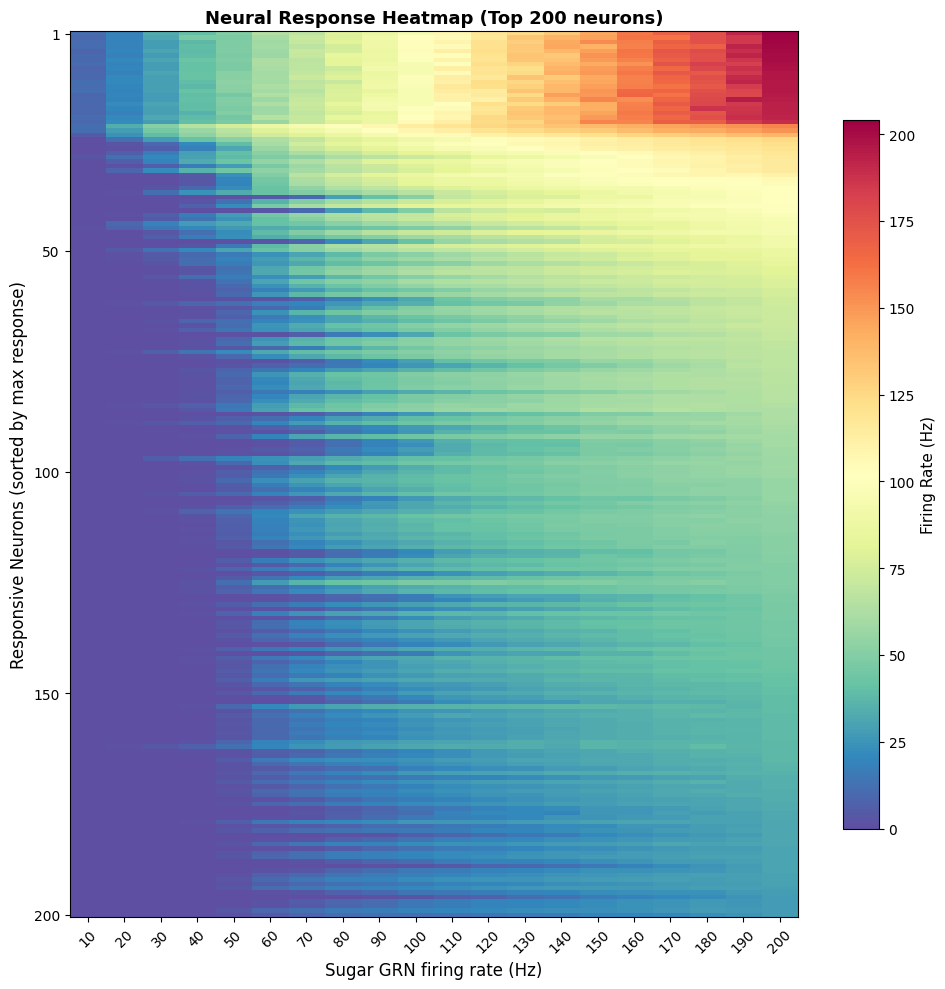

   Showing top 200 neurons


In [32]:

# Plot 2: Response heatmap
print("\nPlot 2: Response heatmap")
fig2, ax2, top_neurons = plot_response_heatmap(
    all_firing_rates, 
    freq_list=sorted(results_dict.keys()),
    # vmax=199, 
    cmap = sns.color_palette("Spectral_r", as_cmap=True),
    top_n=None,  # Auto-detect
    preset='auto',  # Data-driven
    # save_path=output_dir / 'response_heatmap.png'
)

plt.show()

print(f"   Showing top {len(top_neurons)} neurons")


Plot 3: MN9 frequency response (bilateral)


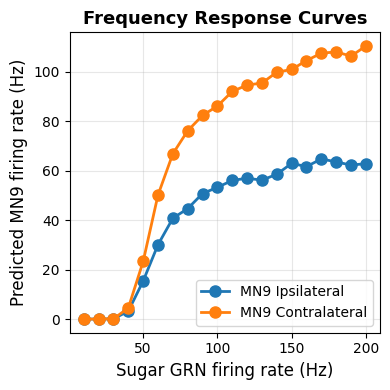

In [33]:
# Plot 3: MN9 response curve (if MN9 defined)
if 'NEU_MN9_RIGHT' in dir() and NEU_MN9_RIGHT:
    print("\nPlot 3: MN9 frequency response (bilateral)")
    
    # 合并同侧和对侧
    target_neurons = NEU_MN9_LEFT + NEU_MN9_RIGHT
    labels = ['MN9 Ipsilateral', 'MN9 Contralateral']
    
    fig3, ax3 = plot_frequency_response_curve(
        all_firing_rates,
        figsize=(4, 4),
        freq_list=sorted(results_dict.keys()),
        target_neurons=target_neurons,
        labels=labels,
        save_path=output_dir / 'mn9_bilateral_response.png'
    )
    plt.show()


Plot 4: Summary statistics


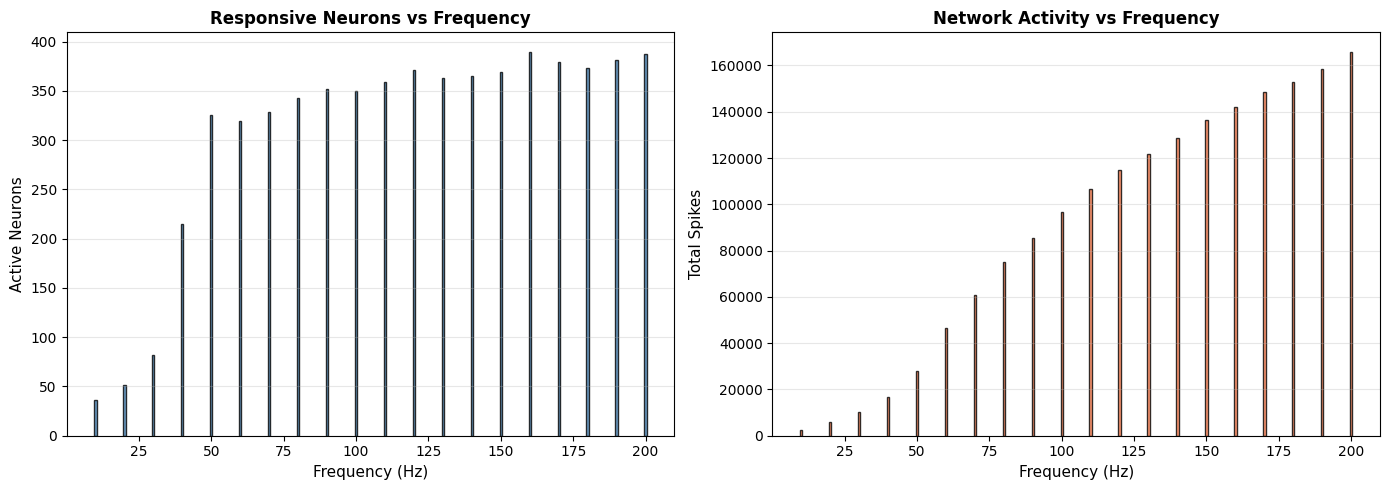


✅ All plots saved to: results/exp1_full


In [73]:
# Plot 4: Summary statistics
print("\nPlot 4: Summary statistics")
fig4, axes4 = plot_summary_statistics(
    df_summary,
    save_path=output_dir / 'summary_stats.png'
)
plt.show()

print(f"\n✅ All plots saved to: {output_dir}")

### 5.4 Save complete results

In [ ]:
# ==================== Cell 12: 保存完整结果 ====================
print("\n" + "=" * 70)
print("Saving Results")
print("=" * 70)

# Save complete results
results_package = {
    'results_dict': results_dict,
    'all_firing_rates': all_firing_rates,
    'df_summary': df_summary,
    'parameters': {
        'freq_list': sorted(results_dict.keys()),
        'n_trials': 10,
        'n_frequencies': len(results_dict),
        'neurons_activated': len(NEU_SUGAR_LEFT),
    },
    'validation': {
        'correlation_100Hz': r if has_original else None,
        'top_neurons': top_neurons,
    }
}

# Save
with open(output_dir / 'exp1_complete_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)

# Save summary CSV
df_summary.to_csv(output_dir / 'summary.csv', index=False)

# Save firing rate matrix
if all_firing_rates:
    # Create DataFrame (neurons × frequencies)
    all_freqs = sorted(results_dict.keys())
    all_neurons = set()
    for rates_dict in all_firing_rates.values():
        all_neurons.update(rates_dict.keys())
    
    rate_matrix = pd.DataFrame(index=sorted(all_neurons), columns=all_freqs)
    for freq in all_freqs:
        for neuron_id, rate in all_firing_rates[freq].items():
            rate_matrix.loc[neuron_id, freq] = rate
    
    rate_matrix.fillna(0).to_csv(output_dir / 'firing_rate_matrix.csv')
    print(f"   ✓ firing_rate_matrix.csv ({rate_matrix.shape[0]} neurons × {rate_matrix.shape[1]} freqs)")

print(f"\n✅ Complete results saved:")
print(f"   - exp1_complete_results.pkl (full data)")
print(f"   - summary.csv (table)")
print(f"   - firing_rate_matrix.csv (neurons × frequencies)")
print(f"   - 4 figures (.png)")

print("\n" + "=" * 70)
print("✅ Experiment 1 Complete!")
print("=" * 70)
print(f"\nKey results:")
print(f"  Frequencies tested: {len(results_dict)}")
print(f"  Total active neurons: {len(all_neurons)}")
if has_original:
    print(f"  Correlation with paper: r = {r:.4f}")
print(f"\nOutput: {output_dir}/")

## 6 Save Top 200 neurons

In [14]:
# ==================== Cell 13: Save Top 200 neurons ====================
print("\n" + "=" * 70)
print("Saving Top 200 Responsive Neurons")
print("=" * 70)

# 按200Hz firing rate排序（与原论文一致）
if 200 in all_firing_rates:
    rates_200hz = pd.Series(all_firing_rates[200])
    top_200_neurons = rates_200hz.sort_values(ascending=False).head(200).index.tolist()
    
    print(f"\nTop 200 neurons (by 200Hz response):")
    print(f"  Count: {len(top_200_neurons)}")
    print(f"  Min rate: {rates_200hz[top_200_neurons[-1]]:.2f} Hz")
    print(f"  Max rate: {rates_200hz[top_200_neurons[0]]:.2f} Hz")
    
    # 保存（供Exp2使用）
    np.save(output_dir / 'top_200_neurons.npy', top_200_neurons)
    
    # 也保存为文本（可读）
    with open(output_dir / 'top_200_neurons.txt', 'w') as f:
        f.write("# Top 200 neurons by 200Hz firing rate\n")
        f.write("# For Exp2 sufficiency test\n")
        for i, nid in enumerate(top_200_neurons, 1):
            f.write(f"{i:3d}. {nid} ({rates_200hz[nid]:.2f} Hz)\n")
    
    print(f"\n✅ Saved:")
    print(f"   - top_200_neurons.npy (for code)")
    print(f"   - top_200_neurons.txt (readable)")
    
else:
    print("\n⚠️ No 200Hz data, cannot select Top 200")


Saving Top 200 Responsive Neurons

Top 200 neurons (by 200Hz response):
  Count: 200
  Min rate: 27.30 Hz
  Max rate: 204.10 Hz

✅ Saved:
   - top_200_neurons.npy (for code)
   - top_200_neurons.txt (readable)


# Exp2 Sufficiency Test
## 7: Experiment 2 - Sufficiency Test

**Purpose**
Test which neurons can activate MN9 when individually stimulated.

Configuration
- **Neurons**: Top 20 (for quick test)
- **Frequencies**: [50, 100] Hz
- **Trials**: 1 (match baseline)
- **Method**: Parallel execution (3 workers)

Expected Runtime
- Baseline (unoptimized): ~9.6 minutes
- Optimized (parallel): ~2-3 minutes
- Speedup: ~4×

---
run section 1-3, 4.5, 5.1, 5.3, 6 first
### Cell 7.2: Code - Import & Configuration

In [16]:
# ==================== Cell 7.2: Exp2配置（5批×40神经元） ====================

from flylif.core.experiments import run_exp2_parallel
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import MemoryMonitor, print_memory, check_memory_safe
import gc

print("=" * 70)
print("Experiment 2: Sufficiency Test - 5 Batches")
print("=" * 70)

# Split 200 neurons into 5 batches (40 each)
BATCH_CONFIG_EXP2 = {
    'batch1': (0, 40),      # Neurons 1-40
    'batch2': (40, 80),     # Neurons 41-80
    'batch3': (80, 120),    # Neurons 81-120
    'batch4': (120, 160),   # Neurons 121-160
    'batch5': (160, 200),   # Neurons 161-200
}

FREQS_EXP2 = [50, 100]
N_TRIALS_EXP2 = 1
TARGET_MN9 = NEU_MN9_RIGHT

print(f"\nConfiguration:")
print(f"  Total neurons: 200 (split into 5 batches of 40)")
print(f"  Frequencies: {FREQS_EXP2}")
print(f"  Trials/condition: {N_TRIALS_EXP2}")
print(f"  Workers: 3")
print(f"  Tasks/batch: 40×2 = 80")
print(f"\nProjected time:")
print(f"  Per batch: ~3 minutes")
print(f"  Total (5 batches): ~15 minutes")

# Initialize checkpoint
checkpoint_dir = Path('./checkpoints/exp2_test')
ckpt_exp2 = CheckpointManager(checkpoint_dir)

print(f"\nCheckpoint: {checkpoint_dir}")
print_memory("\nInitial memory: ")

Experiment 2: Sufficiency Test - 5 Batches

Configuration:
  Total neurons: 200 (split into 5 batches of 40)
  Frequencies: [50, 100]
  Trials/condition: 1
  Workers: 3
  Tasks/batch: 40×2 = 80

Projected time:
  Per batch: ~3 minutes
  Total (5 batches): ~15 minutes

Checkpoint: checkpoints/exp2_test

Initial memory: Memory: 42.2% used, 9.9GB free, Swap: 0.0GB


{'used_gb': 7.250460672,
 'available_gb': 9.924517888,
 'percent': 42.2,
 'swap_gb': 0.0}

### Cell 7.3: Batch simulations

In [18]:
# ==================== Cell 7.3A: Exp2 Batch 1 ====================

print("\n" + "=" * 70)
print("Exp2 Batch 1: Neurons 1-40")
print("=" * 70)

# Check if already completed
batch_key = 'batch1'
if ckpt_exp2.is_completed(batch_key):
    print(f"✅ Batch 1 already completed, loading...")
    results_exp2_batch1 = ckpt_exp2.load(batch_key)
else:
    start, end = BATCH_CONFIG_EXP2['batch1']
    neurons_batch1 = top_200_neurons[start:end]
    
    print(f"Neurons: {start+1}-{end}")
    print(f"Tasks: {len(neurons_batch1) * len(FREQS_EXP2)}")
    
    t0 = time()
    
    with MemoryMonitor(label="Batch1"):
        results_exp2_batch1 = run_exp2_parallel(
            data=DATA,
            neurons_to_test=neurons_batch1,
            freqs=FREQS_EXP2,
            target_neurons=TARGET_MN9,
            params=DEFAULT_PARAMS,
            n_trials=N_TRIALS_EXP2,
            n_workers=3,
            verbose=True
        )
    
    batch1_time = time() - t0
    print(f"\n⏱️  Batch 1 time: {batch1_time/60:.1f} min")
    
    # Save checkpoint
    ckpt_exp2.save(batch_key, results_exp2_batch1)
    print(f"✅ Saved to checkpoint")

print_memory("\nAfter Batch 1: ")

# Check memory before proceeding
is_safe, msg = check_memory_safe(threshold=75.0)
if not is_safe:
    print(f"\n⚠️  {msg}")
    print("   Recommend: Kernel → Restart before Batch 2")
else:
    print(f"\n✅ Memory OK, can proceed to Batch 2")


Exp2 Batch 1: Neurons 1-40
Neurons: 1-40
Tasks: 80
[Batch1] Start - Memory: 47.8%

Exp2: Sufficiency Test (Parallel)
  Neurons: 40
  Frequencies: [50, 100]
  Trials/condition: 1
  Workers: 3
  Total tasks: 80

  Running 80 tasks...


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:  1.1min
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed:  6.1min



  ✅ Complete! Total: 7.6 min
[Batch1] End - Memory: 54.5% (Δ+1.1GB)

⏱️  Batch 1 time: 7.6 min
✅ Saved to checkpoint

After Batch 1: Memory: 54.5% used, 7.8GB free, Swap: 1.7GB

⚠️  ⚠️ Swap active: 1.7GB
   Recommend: Kernel → Restart before Batch 2


[Parallel(n_jobs=3)]: Done  80 out of  80 | elapsed:  7.6min finished


In [17]:
# ==================== Cell 7.3B: Exp2 Batch 2 ====================
# ⚠️  如果内存高，先 Restart Kernel → Re-run Cells 1-6 → 再运行此cell

print("\n" + "=" * 70)
print("Exp2 Batch 2: Neurons 41-80")
print("=" * 70)

batch_key = 'batch2'
if ckpt_exp2.is_completed(batch_key):
    print(f"✅ Already completed")
    results_exp2_batch2 = ckpt_exp2.load(batch_key)
else:
    start, end = BATCH_CONFIG_EXP2['batch2']
    neurons_batch2 = top_200_neurons[start:end]
    
    print(f"Neurons: {start+1}-{end}")
    
    t0 = time()
    with MemoryMonitor(label="Batch2"):
        results_exp2_batch2 = run_exp2_parallel(
            data=DATA,
            neurons_to_test=neurons_batch2,
            freqs=FREQS_EXP2,
            target_neurons=TARGET_MN9,
            params=DEFAULT_PARAMS,
            n_trials=N_TRIALS_EXP2,
            n_workers=3,
            verbose=True
        )
    
    print(f"\n⏱️  Batch 2 time: {(time()-t0)/60:.1f} min")
    ckpt_exp2.save(batch_key, results_exp2_batch2)

print_memory("\nAfter Batch 2: ")


Exp2 Batch 2: Neurons 41-80
Neurons: 41-80
[Batch2] Start - Memory: 42.3%

Exp2: Sufficiency Test (Parallel)
  Neurons: 40
  Frequencies: [50, 100]
  Trials/condition: 1
  Workers: 3
  Total tasks: 80

  Running 80 tasks...


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:  1.1min
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed:  5.8min



  ✅ Complete! Total: 7.0 min
[Batch2] End - Memory: 45.5% (Δ+0.5GB)

⏱️  Batch 2 time: 7.0 min

After Batch 2: Memory: 45.5% used, 9.4GB free, Swap: 0.0GB


[Parallel(n_jobs=3)]: Done  80 out of  80 | elapsed:  7.0min finished


{'used_gb': 7.806230528,
 'available_gb': 9.36830976,
 'percent': 45.5,
 'swap_gb': 0.0}

In [18]:
# ==================== Cell 7.3C: Exp2 Batch 3 ====================
# ⚠️  Check memory first

print("\n" + "=" * 70)
print("Exp2 Batch 3: Neurons 81-120 (Testing 4 workers)")
print("=" * 70)

batch_key = 'batch3'
if ckpt_exp2.is_completed(batch_key):
    results_exp2_batch3 = ckpt_exp2.load(batch_key)
else:
    start, end = BATCH_CONFIG_EXP2['batch3']
    neurons_batch3 = top_200_neurons[start:end]

    print(f"Neurons: {start+1}-{end}")
    print(f"Workers: 4 (increased from 3)")

    t0 = time()
    with MemoryMonitor(label="Batch3(4w)"):
        results_exp2_batch3 = run_exp2_parallel(
            DATA, neurons_batch3, FREQS_EXP2, TARGET_MN9,
            DEFAULT_PARAMS, N_TRIALS_EXP2, n_workers=4, verbose=True
        )
    
    print(f"\n⏱️  {(time()-t0)/60:.1f} min")
    ckpt_exp2.save(batch_key, results_exp2_batch3)

print_memory("\nAfter Batch 3: ")


Exp2 Batch 3: Neurons 81-120 (Testing 4 workers)
Neurons: 81-120
Workers: 4 (increased from 3)
[Batch3(4w)] Start - Memory: 43.1%

Exp2: Sufficiency Test (Parallel)
  Neurons: 40
  Frequencies: [50, 100]
  Trials/condition: 1
  Workers: 4
  Total tasks: 80

  Running 80 tasks...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   59.9s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  4.8min



  ✅ Complete! Total: 5.9 min
[Batch3(4w)] End - Memory: 47.6% (Δ+0.8GB)

⏱️  5.9 min

After Batch 3: Memory: 47.6% used, 9.0GB free, Swap: 0.0GB


[Parallel(n_jobs=4)]: Done  80 out of  80 | elapsed:  5.9min finished


{'used_gb': 8.178597888,
 'available_gb': 8.996769792,
 'percent': 47.6,
 'swap_gb': 0.0}

In [19]:
# ==================== Cell 7.3D: Exp2 Batch 4 (4 workers) ====================

print("\n" + "=" * 70)
print("Exp2 Batch 4: Neurons 121-160")
print("=" * 70)

batch_key = 'batch4'
if ckpt_exp2.is_completed(batch_key):
    results_exp2_batch4 = ckpt_exp2.load(batch_key)
    print("✅ Already completed")
else:
    start, end = BATCH_CONFIG_EXP2['batch4']
    neurons_batch4 = top_200_neurons[start:end]
    
    print(f"Neurons: {start+1}-{end}")
    print(f"Workers: 4")
    
    t0 = time()
    with MemoryMonitor(label="Batch4"):
        results_exp2_batch4 = run_exp2_parallel(
            DATA, neurons_batch4, FREQS_EXP2, TARGET_MN9,
            DEFAULT_PARAMS, N_TRIALS_EXP2, 
            n_workers=4,  # ← 4 workers
            verbose=True
        )
    
    print(f"\n⏱️  {(time()-t0)/60:.1f} min")
    ckpt_exp2.save(batch_key, results_exp2_batch4)

print_memory("\nAfter Batch 4: ")


Exp2 Batch 4: Neurons 121-160
Neurons: 121-160
Workers: 4
[Batch4] Start - Memory: 48.2%

Exp2: Sufficiency Test (Parallel)
  Neurons: 40
  Frequencies: [50, 100]
  Trials/condition: 1
  Workers: 4
  Total tasks: 80

  Running 80 tasks...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   58.2s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  4.9min



  ✅ Complete! Total: 6.2 min
[Batch4] End - Memory: 48.9% (Δ+0.1GB)

⏱️  6.2 min

After Batch 4: Memory: 48.9% used, 8.8GB free, Swap: 0.0GB


[Parallel(n_jobs=4)]: Done  80 out of  80 | elapsed:  6.2min finished


{'used_gb': 8.398073856,
 'available_gb': 8.776794112,
 'percent': 48.9,
 'swap_gb': 0.0}

In [20]:
# ==================== Cell 7.3E: Exp2 Batch 5 - Final (4 workers) ====================

print("\n" + "=" * 70)
print("Exp2 Batch 5 (Final): Neurons 161-200")
print("=" * 70)

batch_key = 'batch5'
if ckpt_exp2.is_completed(batch_key):
    results_exp2_batch5 = ckpt_exp2.load(batch_key)
    print("✅ Already completed")
else:
    start, end = BATCH_CONFIG_EXP2['batch5']
    neurons_batch5 = top_200_neurons[start:end]
    
    print(f"Neurons: {start+1}-{end}")
    print(f"Workers: 4")
    
    t0 = time()
    with MemoryMonitor(label="Batch5"):
        results_exp2_batch5 = run_exp2_parallel(
            DATA, neurons_batch5, FREQS_EXP2, TARGET_MN9,
            DEFAULT_PARAMS, N_TRIALS_EXP2, 
            n_workers=4,
            verbose=True
        )
    
    print(f"\n⏱️  {(time()-t0)/60:.1f} min")
    ckpt_exp2.save(batch_key, results_exp2_batch5)

print_memory("\nAfter Batch 5: ")
print("\n" + "=" * 70)
print("✅ All 5 Exp2 Batches Complete!")
print("=" * 70)


Exp2 Batch 5 (Final): Neurons 161-200
Neurons: 161-200
Workers: 4
[Batch5] Start - Memory: 49.4%

Exp2: Sufficiency Test (Parallel)
  Neurons: 40
  Frequencies: [50, 100]
  Trials/condition: 1
  Workers: 4
  Total tasks: 80

  Running 80 tasks...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   59.6s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  5.2min



  ✅ Complete! Total: 6.8 min
[Batch5] End - Memory: 50.6% (Δ+0.2GB)

⏱️  6.8 min

After Batch 5: Memory: 50.6% used, 8.5GB free, Swap: 0.0GB

✅ All 5 Exp2 Batches Complete!


[Parallel(n_jobs=4)]: Done  80 out of  80 | elapsed:  6.8min finished


---

### Cell 7.4: merge all batches

In [36]:
# ==================== Cell 7.4: 合并所有Exp2批次 ====================

print("\n" + "=" * 70)
print("Merging All Exp2 Batches")
print("=" * 70)

# Load all from checkpoint
all_batches = []
for batch_key in ['batch1', 'batch2', 'batch3', 'batch4', 'batch5']:
    batch_result = ckpt_exp2.load(batch_key)
    if batch_result:
        all_batches.append(batch_result)
    else:
        print(f"⚠️  {batch_key} not found")

print(f"Loaded {len(all_batches)} batches")

# Merge
results_exp2 = {}
for freq in FREQS_EXP2:
    results_exp2[freq] = {}
    for batch in all_batches:
        results_exp2[freq].update(batch[freq])

print(f"\n✅ Merged results:")
for freq in FREQS_EXP2:
    print(f"  {freq} Hz: {len(results_exp2[freq])} neurons")

# Validation (same as Cell 7.5)
for freq in FREQS_EXP2:
    mn9_means = [stats['mean'] for stats in results_exp2[freq].values()]
    n_activate = sum(1 for m in mn9_means if m > 0)
    
    print(f"\n{freq} Hz:")
    print(f"  Neurons activating MN9: {n_activate}/200")
    print(f"  MN9 range: {min(mn9_means):.1f} - {max(mn9_means):.1f} Hz")


Merging All Exp2 Batches
Loaded 5 batches

✅ Merged results:
  50 Hz: 200 neurons
  100 Hz: 200 neurons

50 Hz:
  Neurons activating MN9: 38/200
  MN9 range: 0.0 - 70.0 Hz

100 Hz:
  Neurons activating MN9: 44/200
  MN9 range: 0.0 - 108.0 Hz


---

### Cell 7.5: Code - Results Validation


Exp2 Visualization
Generating heatmap (matching Exp1 neuron order)...


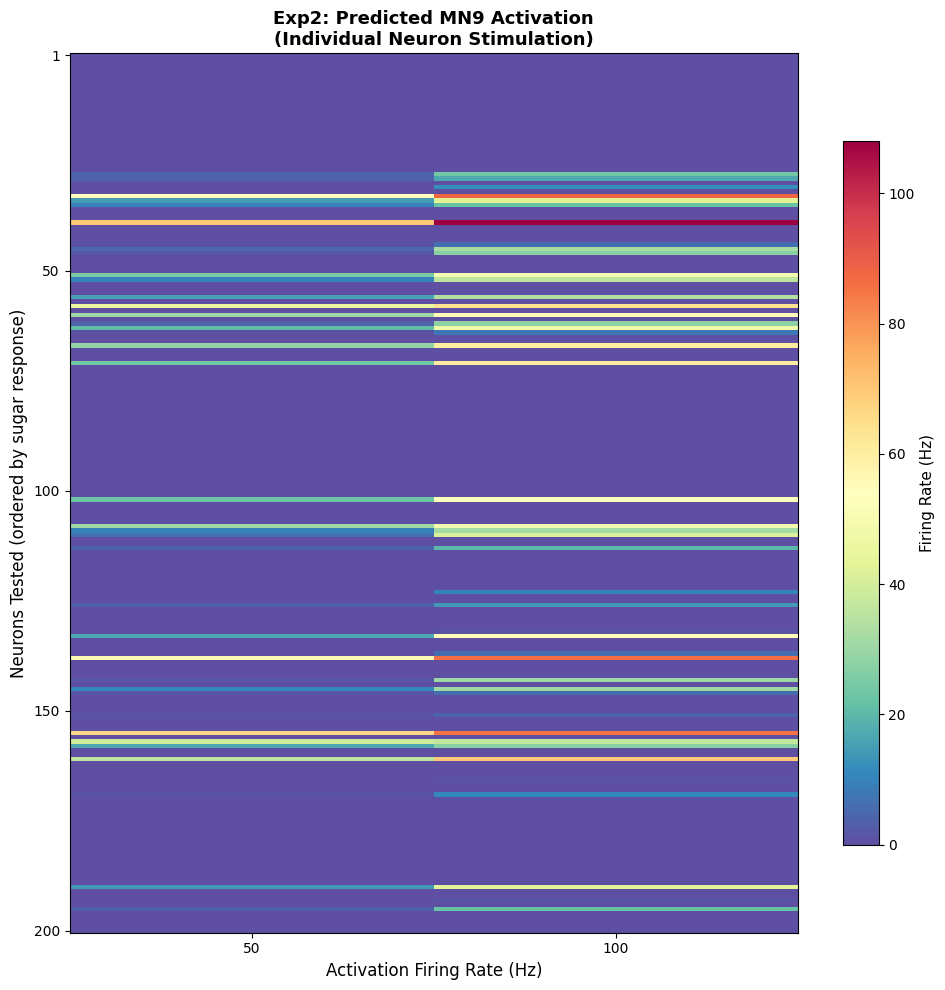


✅ Heatmap generated (neuron order matches Exp1)


In [63]:
# ==================== Cell 7.5: Exp2可视化（保持Exp1顺序） ====================

from flylif.utils.visualization import plot_response_heatmap

print("\n" + "=" * 70)
print("Exp2 Visualization")
print("=" * 70)

# 数据转换
all_firing_rates_exp2 = {}
for freq in FREQS_EXP2:
    all_firing_rates_exp2[freq] = {
        nid: stats['mean'] 
        for nid, stats in results_exp2[freq].items()
    }

# Plot（保持Exp1的神经元顺序）
print("Generating heatmap (matching Exp1 neuron order)...")

fig, ax, _ = plot_response_heatmap(
    all_firing_rates=all_firing_rates_exp2,
    freq_list=FREQS_EXP2,  # 不sorted
    neuron_order=top_200_neurons,  # ← 关键：使用Exp1顺序
    # vmax=199, 
    cmap = sns.color_palette("Spectral_r", as_cmap=True),
    # save_path='./results/exp2_test/exp2_heatmap.png'
)

# 修改labels（Exp2特定）
ax.set_xlabel('Activation Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Neurons Tested (ordered by sugar response)', fontsize=12)
ax.set_title('Exp2: Predicted MN9 Activation\n(Individual Neuron Stimulation)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Heatmap generated (neuron order matches Exp1)")


[2/3] Generating summary statistics...


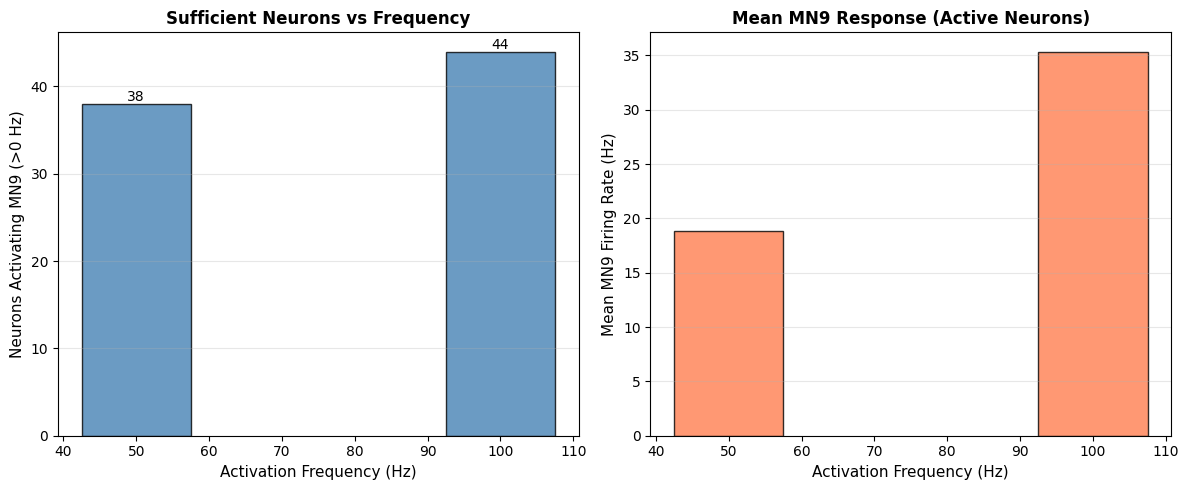

  ✅ Summary charts generated


In [33]:
# ===== Plot 2: Summary Bar Chart =====
print(f"\n[2/3] Generating summary statistics...")

# Count neurons that activate MN9 at each frequency
summary_data = []
for freq in sorted(FREQS_EXP2):
    mn9_rates = [stats['mean'] for stats in results_exp2[freq].values()]
    n_activate = sum(1 for r in mn9_rates if r > 0)
    max_rate = max(mn9_rates)
    mean_rate = np.mean([r for r in mn9_rates if r > 0]) if n_activate > 0 else 0
    
    summary_data.append({
        'Frequency': freq,
        'N_Activate_MN9': n_activate,
        'Max_MN9_Rate': max_rate,
        'Mean_MN9_Rate': mean_rate,
    })

df_summary_exp2 = pd.DataFrame(summary_data)

# Plot
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Count
ax2a = axes[0]
bars = ax2a.bar(df_summary_exp2['Frequency'], df_summary_exp2['N_Activate_MN9'],
                color='steelblue', edgecolor='black', alpha=0.8, width=15)
ax2a.set_xlabel('Activation Frequency (Hz)', fontsize=11)
ax2a.set_ylabel('Neurons Activating MN9 (>0 Hz)', fontsize=11)
ax2a.set_title('Sufficient Neurons vs Frequency', fontsize=12, fontweight='bold')
ax2a.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2a.text(bar.get_x() + bar.get_width()/2., height,
              f'{int(height)}', ha='center', va='bottom', fontsize=10)

# Panel B: Mean MN9 rate
ax2b = axes[1]
ax2b.bar(df_summary_exp2['Frequency'], df_summary_exp2['Mean_MN9_Rate'],
         color='coral', edgecolor='black', alpha=0.8, width=15)
ax2b.set_xlabel('Activation Frequency (Hz)', fontsize=11)
ax2b.set_ylabel('Mean MN9 Firing Rate (Hz)', fontsize=11)
ax2b.set_title('Mean MN9 Response (Active Neurons)', fontsize=12, fontweight='bold')
ax2b.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"  ✅ Summary charts generated")


[3/3] Generating top neurons response curves...


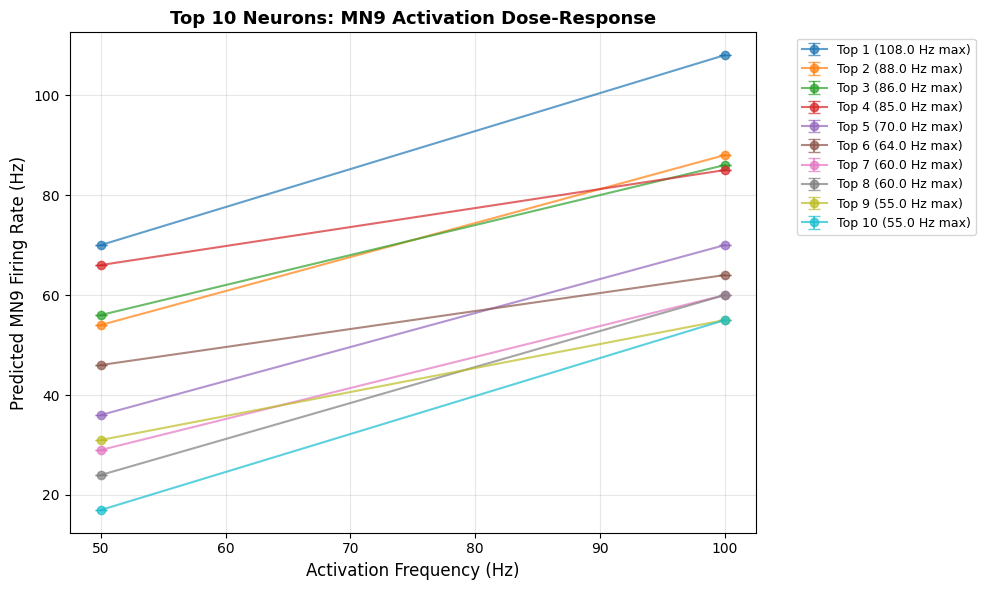

  ✅ Response curves generated


In [70]:
# ===== Plot 3: Top Neurons Response Curves =====
print(f"\n[3/3] Generating top neurons response curves...")

# Get top 10 neurons by max MN9 activation
all_max_rates = {}
for nid in results_exp2[FREQS_EXP2[0]].keys():
    max_rate = max(results_exp2[freq][nid]['mean'] for freq in FREQS_EXP2)
    all_max_rates[nid] = max_rate

top_10_neurons = sorted(all_max_rates.items(), key=lambda x: x[1], reverse=True)[:10]

fig3, ax3 = plt.subplots(figsize=(10, 6))

for i, (nid, max_rate) in enumerate(top_10_neurons):
    rates = [results_exp2[freq][nid]['mean'] for freq in sorted(FREQS_EXP2)]
    stds = [results_exp2[freq][nid]['std'] for freq in sorted(FREQS_EXP2)]
    
    ax3.errorbar(sorted(FREQS_EXP2), rates, yerr=stds,
                 marker='o', markersize=6, capsize=4,
                 linewidth=1.5, alpha=0.7, 
                 label=f'Top {i+1} ({max_rate:.1f} Hz max)',
                 )

ax3.set_xlabel('Activation Frequency (Hz)', fontsize=12)
ax3.set_ylabel('Predicted MN9 Firing Rate (Hz)', fontsize=12)
ax3.set_title('Top 10 Neurons: MN9 Activation Dose-Response', 
              fontsize=13, fontweight='bold')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(output_dir / 'exp2_top10_response_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Response curves generated")

In [35]:
# ===== Summary Table =====
print(f"\n" + "=" * 70)
print("Exp2 Summary Statistics")
print("=" * 70)
print(df_summary_exp2.to_string(index=False))

print(f"\nTop 10 neurons by max MN9 activation:")
for i, (nid, max_rate) in enumerate(top_10_neurons, 1):
    rates_str = ", ".join([f"{results_exp2[f][nid]['mean']:.1f}" for f in sorted(FREQS_EXP2)])
    print(f"  {i:2d}. {nid}: [{rates_str}] Hz")


Exp2 Summary Statistics
 Frequency  N_Activate_MN9  Max_MN9_Rate  Mean_MN9_Rate
        50              38          70.0      18.815789
       100              44         108.0      35.363636

Top 10 neurons by max MN9 activation:
   1. 720575940623211725: [70.0, 108.0] Hz
   2. 720575940660219265: [54.0, 88.0] Hz
   3. 720575940632365905: [56.0, 86.0] Hz
   4. 720575940624023188: [66.0, 85.0] Hz
   5. 720575940627099338: [36.0, 70.0] Hz
   6. 720575940607272649: [46.0, 64.0] Hz
   7. 720575940632252743: [29.0, 60.0] Hz
   8. 720575940609407939: [24.0, 60.0] Hz
   9. 720575940610001220: [31.0, 55.0] Hz
  10. 720575940660223873: [17.0, 55.0] Hz


---

### 7.6: Code - Save Results

In [66]:
# ==================== Cell 7.6: 保存Exp2完整结果（修复版） ====================

output_dir = Path('./results/exp2_test')
output_dir.mkdir(parents=True, exist_ok=True)

print("\n" + "=" * 70)
print("Saving Exp2 Results")
print("=" * 70)

# ===== 计算summary statistics =====
summary_data = []
for freq in FREQS_EXP2:
    mn9_rates = [stats['mean'] for stats in results_exp2[freq].values()]
    n_activate = sum(1 for r in mn9_rates if r > 0)
    
    summary_data.append({
        'Frequency': freq,
        'N_Activate_MN9': n_activate,
        'N_Total': len(results_exp2[freq]),
        'Percent_Active': f"{100*n_activate/len(results_exp2[freq]):.1f}%",
        'Max_MN9_Hz': max(mn9_rates),
        'Mean_MN9_Hz': np.mean([r for r in mn9_rates if r > 0]) if n_activate > 0 else 0,
    })

df_summary_exp2 = pd.DataFrame(summary_data)

# ===== 保存完整结果 =====
exp2_package = {
    'neurons_tested': list(top_200_neurons),  # ← 修复：兼容list和array
    'freqs': FREQS_EXP2,
    'n_trials': N_TRIALS_EXP2,
    'target_neurons': TARGET_MN9,  # ← 修复：变量名
    'results': results_exp2,
    'summary': df_summary_exp2.to_dict(),
    'parameters': {
        'n_batches': 5,
        'neurons_per_batch': 40,
        'n_workers': 4,
    },
    'notes': 'Exp2 sufficiency test: 200 neurons × 2 frequencies × 1 trial'
}

with open(output_dir / 'exp2_results_200neurons.pkl', 'wb') as f:
    pickle.dump(exp2_package, f)

# 保存summary CSV
df_summary_exp2.to_csv(output_dir / 'exp2_summary.csv', index=False)

# 保存firing rate matrix
rate_matrix_exp2 = pd.DataFrame(
    {freq: [results_exp2[freq][nid]['mean'] for nid in top_200_neurons]
     for freq in FREQS_EXP2},
    index=top_200_neurons
)
rate_matrix_exp2.to_csv(output_dir / 'exp2_firing_rate_matrix.csv')

print(f"\n✅ Results saved:")
print(f"   {output_dir}/exp2_results_200neurons.pkl")
print(f"   {output_dir}/exp2_summary.csv")
print(f"   {output_dir}/exp2_firing_rate_matrix.csv")

print(f"\n" + "=" * 70)
print("Exp2 Summary")
print("=" * 70)
print(df_summary_exp2.to_string(index=False))


Saving Exp2 Results

✅ Results saved:
   results/exp2_test/exp2_results_200neurons.pkl
   results/exp2_test/exp2_summary.csv
   results/exp2_test/exp2_firing_rate_matrix.csv

Exp2 Summary
 Frequency  N_Activate_MN9  N_Total Percent_Active  Max_MN9_Hz  Mean_MN9_Hz
        50              38      200          19.0%        70.0    18.815789
       100              44      200          22.0%       108.0    35.363636


# 8: Experiment 3 - Necessity Test (Silencing)

## Test 1: Minimal Validation (2 neurons × 2 freqs × 10T)

**Purpose**
- Validate Exp3 logic (control + silencing)
- Observe memory accumulation pattern (10 trials)
- Test silencing mechanism works correctly

**Configuration**
- **Neurons to silence**: 2 neurons (21-22, skip first 20 GRNs)
- **Frequencies**: [50, 100] Hz
- **Trials**: 10 (match full-scale target)
- **Workers**: 1 (serial, for clean observation)
- **Expected runtime**: 2-3 minutes

**Memory Watch**
- Each simulation may leave ~15MB residue
- 2 neurons × 2 freqs × (1 control) = 5 simulations
- Expected accumulation: ~75MB (negligible)

---

## 8.1

In [17]:
# ==================== Cell 8.2: Exp3测试1配置 ====================

from flylif.utils.memory_utils import MemoryMonitor, print_memory
import gc

print("=" * 70)
print("Exp3 Test 1: Minimal Validation (2×2×10T, Worker Mode)")
print("=" * 70)

# Configuration
NEU_ACTIVATE = NEU_SUGAR_LEFT
NEURONS_SILENCE_TEST = top_200_neurons[20:22]   # 2 neurons (skip GRNs)
FREQS_TEST1 = [50, 100]
N_TRIALS_TEST1 = 10
TARGET_MN9_TEST = NEU_MN9_RIGHT

print(f"\nConfiguration:")
print(f"  Activated: {len(NEU_ACTIVATE)} Sugar GRNs")
print(f"  To silence: {len(NEURONS_SILENCE_TEST)} neurons (IDs: {list(NEURONS_SILENCE_TEST)})")
print(f"  Frequencies: {FREQS_TEST1}")
print(f"  Trials: {N_TRIALS_TEST1}")
print(f"  Total tasks: {len(FREQS_TEST1) + len(NEURONS_SILENCE_TEST)*len(FREQS_TEST1)}")
print(f"    - Control: {len(FREQS_TEST1)}")
print(f"    - Silencing: {len(NEURONS_SILENCE_TEST) * len(FREQS_TEST1)}")
print(f"\n  Method: Parallel workers (n_jobs=2, avoid start_scope conflict)")

print_memory("\nInitial memory: ")

Exp3 Test 1: Minimal Validation (2×2×10T, Worker Mode)

Configuration:
  Activated: 21 Sugar GRNs
  To silence: 2 neurons (IDs: [720575940624963786, 720575940622695448])
  Frequencies: [50, 100]
  Trials: 10
  Total tasks: 6
    - Control: 2
    - Silencing: 4

  Method: Parallel workers (n_jobs=2, avoid start_scope conflict)

Initial memory: Memory: 45.1% used, 9.4GB free, Swap: 0.0GB


{'used_gb': 7.704223744,
 'available_gb': 9.43104,
 'percent': 45.1,
 'swap_gb': 0.0}

In [78]:
# ==================== Cell 8.3A: Exp3 Worker函数定义 ====================

def exp3_single_condition_worker(condition_type, neuron_id, freq, neu_exc, 
                                 data, params, target_neurons, n_trials):
    """
    Single condition worker (control or silencing).
    
    Each worker runs in independent process to avoid start_scope conflicts.
    
    Parameters
    ----------
    condition_type : str
        'control' or 'silencing'
    neuron_id : int or None
        Neuron to silence (None for control)
    freq : int
        Frequency (Hz)
    neu_exc : list
        Neurons to activate
    ...
    
    Returns
    -------
    tuple : (condition_type, freq, neuron_id, stats)
    """
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    import gc
    
    # Build network (in independent process)
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    # Run simulation
    if condition_type == 'control':
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=False
        )
    else:  # silencing
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            neu_slnc=[neuron_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=False
        )
    
    df = result['df']
    duration_s = float(params['t_run'] / ms) / 1000
    
    # Calculate target rates per trial
    target_rates = []
    for trial in range(n_trials):
        trial_df = df[df['trial'] == trial]
        count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                   for tid in target_neurons)
        target_rates.append(count / duration_s)
    
    stats = {
        'mean': np.mean(target_rates),
        'std': np.std(target_rates),
    }
    
    # Cleanup
    del NET
    del result
    gc.collect()
    
    return (condition_type, freq, neuron_id, stats)

print("✅ Worker function defined")

✅ Worker function defined


### debug

In [80]:
# ==================== Cell 8.3_debug: 测试worker基本功能 ====================

from joblib import Parallel, delayed

def simple_worker_test(task_id, data):
    """最简单的worker，只build网络"""
    from flylif.core.network import build_network
    from time import time
    
    print(f"  Worker {task_id} started")
    t0 = time()
    
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=DEFAULT_PARAMS,
        syn_threshold=5,
        verbose=False
    )
    
    build_time = time() - t0
    n_neurons = NET['n_neurons']
    
    del NET
    
    return (task_id, build_time, n_neurons)

print("\n测试：2个worker各build 1次网络...")
t0 = time()

results = Parallel(n_jobs=2, verbose=10)(
    delayed(simple_worker_test)(i, DATA) for i in range(2)
)

print(f"\n✅ 完成: {time()-t0:.1f}s")
for task_id, build_time, n_neurons in results:
    print(f"  Worker {task_id}: build {build_time:.1f}s, {n_neurons:,} neurons")


测试：2个worker各build 1次网络...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


  Worker 1 started
  Worker 0 started

✅ 完成: 10.2s
  Worker 0: build 7.0s, 139,255 neurons
  Worker 1: build 7.1s, 139,255 neurons


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   10.1s finished
WARNING    The object 'neurons' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/Users/charlottel/MyLibrary/connectome/LIFmodel/LIF_simulation/flylif/core/network.py', line 295, in build_network
    neu = NeuronGroup( [brian2.core.base.unused_brian_object]
WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/Users/charlottel/MyLibrary/connectome/LIFmodel/LIF_simulation/flylif/core/network.py', line 317, in build_network
    syn = Synapses(neu, neu, 'w : volt', on_pre='g += w', [

In [81]:
# ==================== Cell 8.3_debug2: 测试单个control仿真 ====================

from joblib import Parallel, delayed

def test_control_worker(freq, neu_exc, data, params, target_neurons, n_trials):
    """测试完整的control仿真（不含silencing）"""
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    from brian2 import Hz, ms
    import gc
    
    print(f"  Worker: freq={freq} started")
    
    # Build
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    print(f"  Worker: freq={freq} network built, running simulation...")
    
    # Run simulation
    result = run_simulation(
        net_components=NET,
        neu_exc=neu_exc,
        params={'r_poi': freq * Hz},
        n_trials=n_trials,
        verbose=False
    )
    
    df = result['df']
    duration_s = float(params['t_run'] / ms) / 1000
    
    # Calculate MN9
    mn9_rates = []
    for trial in range(n_trials):
        trial_df = df[df['trial'] == trial]
        count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                   for tid in target_neurons)
        mn9_rates.append(count / duration_s)
    
    stats = {
        'mean': np.mean(mn9_rates),
        'std': np.std(mn9_rates),
    }
    
    print(f"  Worker: freq={freq} complete, MN9={stats['mean']:.1f} Hz")
    
    del NET
    gc.collect()
    
    return (freq, stats)

# Test: 只跑2个control（最简单）
print("\n测试：2个control仿真（50Hz + 100Hz）...")
print("⏱️  预计：2 × 30秒 ≈ 1分钟\n")

t0 = time()

tasks = [
    (50, NEU_ACTIVATE, DATA, DEFAULT_PARAMS, TARGET_MN9_TEST, N_TRIALS_TEST1),
    (100, NEU_ACTIVATE, DATA, DEFAULT_PARAMS, TARGET_MN9_TEST, N_TRIALS_TEST1),
]

results = Parallel(n_jobs=2, verbose=10)(
    delayed(test_control_worker)(*task) for task in tasks
)

print(f"\n✅ 完成: {time()-t0:.1f}s")

for freq, stats in results:
    print(f"  {freq} Hz: MN9 = {stats['mean']:.1f} ± {stats['std']:.1f} Hz")

print_memory("\nFinal memory: ")


测试：2个control仿真（50Hz + 100Hz）...
⏱️  预计：2 × 30秒 ≈ 1分钟



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


  Worker: freq=100 started
  Worker: freq=100 network built, running simulation...

✅ 完成: 154.0s
  50 Hz: MN9 = 25.0 ± 6.5 Hz
  100 Hz: MN9 = 85.7 ± 7.2 Hz

Final memory: Memory: 60.1% used, 6.9GB free, Swap: 0.0GB


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  2.6min finished


{'used_gb': 7.849664512,
 'available_gb': 6.853738496,
 'percent': 60.1,
 'swap_gb': 0.022806528}

  Worker: freq=100 complete, MN9=85.7 Hz
  Worker: freq=50 started
  Worker: freq=50 network built, running simulation...
  Worker: freq=50 complete, MN9=25.0 Hz


### test

In [82]:
# ==================== Cell 8.3C: Exp3测试1完整版（6 tasks） ====================

print("\n" + "=" * 70)
print("Exp3 Test 1 Complete: Controls + Silencing")
print("=" * 70)

# Create all tasks
tasks_complete = []

# Control tasks (reuse from debug2 if you want, or rebuild)
print("Creating tasks...")
for freq in FREQS_TEST1:
    tasks_complete.append(('control', None, freq, NEU_ACTIVATE, DATA,
                          DEFAULT_PARAMS, TARGET_MN9_TEST, N_TRIALS_TEST1))

# Silencing tasks
for freq in FREQS_TEST1:
    for neuron_id in NEURONS_SILENCE_TEST:
        tasks_complete.append(('silencing', neuron_id, freq, NEU_ACTIVATE, DATA,
                              DEFAULT_PARAMS, TARGET_MN9_TEST, N_TRIALS_TEST1))

print(f"\nTotal tasks: {len(tasks_complete)}")
print(f"  Controls: {len(FREQS_TEST1)}")
print(f"  Silencing: {len(NEURONS_SILENCE_TEST) * len(FREQS_TEST1)}")
print(f"Workers: 2")
print(f"\n⏱️  Expected: ~4 minutes (6 tasks × 77s / 2 workers)")

t0_complete = time()

with MemoryMonitor(label="Exp3-Test1-Complete"):
    results_complete = Parallel(n_jobs=2, verbose=10)(
        delayed(exp3_single_condition_worker)(*task) for task in tasks_complete
    )

complete_time = time() - t0_complete

print(f"\n✅ Test 1 complete: {complete_time/60:.1f} min")
print_memory("\nFinal memory: ")

# Organize results
results_test1_full = {}
for condition_type, freq, neuron_id, stats in results_complete:
    if freq not in results_test1_full:
        results_test1_full[freq] = {'control': None, 'silencing': {}}
    
    if condition_type == 'control':
        results_test1_full[freq]['control'] = stats
    else:
        results_test1_full[freq]['silencing'][neuron_id] = stats

# Calculate relative %
for freq in FREQS_TEST1:
    ctrl_mean = results_test1_full[freq]['control']['mean']
    for nid, stats in results_test1_full[freq]['silencing'].items():
        stats['relative_%'] = (stats['mean'] / ctrl_mean * 100) if ctrl_mean > 0 else 100

# Display
print("\n" + "=" * 70)
print("Exp3 Test 1 Results")
print("=" * 70)

for freq in FREQS_TEST1:
    ctrl = results_test1_full[freq]['control']
    silencing = results_test1_full[freq]['silencing']
    
    print(f"\n{freq} Hz:")
    print(f"  Control: {ctrl['mean']:.1f} ± {ctrl['std']:.1f} Hz")
    print(f"  Silencing results:")
    
    for nid, stats in silencing.items():
        required = "✓ Required" if stats['relative_%'] < 80 else ""
        print(f"    {nid}: {stats['mean']:.1f} Hz ({stats['relative_%']:.1f}%) {required}")

print("\n✅ Test 1 validation complete")
print(f"   Total time: {complete_time/60:.1f} min")
print(f"   Next: If successful → Test 2 (more neurons)")


Exp3 Test 1 Complete: Controls + Silencing
Creating tasks...

Total tasks: 6
  Controls: 2
  Silencing: 4
Workers: 2

⏱️  Expected: ~4 minutes (6 tasks × 77s / 2 workers)
[Exp3-Test1-Complete] Start - Memory: 58.5%


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:  1.4min
[Parallel(n_jobs=2)]: Done   4 out of   6 | elapsed:  2.8min remaining:  1.4min


[Exp3-Test1-Complete] End - Memory: 59.6% (Δ+0.2GB)

✅ Test 1 complete: 4.2 min

Final memory: Memory: 59.6% used, 6.9GB free, Swap: 0.0GB

Exp3 Test 1 Results

50 Hz:
  Control: 19.4 ± 8.4 Hz
  Silencing results:
    720575940624963786: 18.1 Hz (93.3%) 
    720575940622695448: 37.0 Hz (190.7%) 

100 Hz:
  Control: 90.5 ± 4.4 Hz
  Silencing results:
    720575940624963786: 83.6 Hz (92.4%) 
    720575940622695448: 91.4 Hz (101.0%) 

✅ Test 1 validation complete
   Total time: 4.2 min
   Next: If successful → Test 2 (more neurons)


[Parallel(n_jobs=2)]: Done   6 out of   6 | elapsed:  4.2min finished


# Exp3 Test 2: Single Neuron × 8 Frequencies (Internal Batching)

## Purpose
Test if a single neuron can handle all 8 frequencies with 1 network build.
Validates memory accumulation over 80 simulations (8 freqs × 10 trials).

## Configuration
- **Neuron**: 1 neuron (ID 21, first non-GRN)
- **Frequencies**: 8 frequencies [50, 60, 70, 80, 90, 100, 110, 120] Hz
- **Internal batching**: Split into 2 sub-batches (4 freqs each)
  - Batch 1: [50, 60, 70, 80] → 40 simulations
  - Batch 2: [90, 100, 110, 120] → 40 simulations
- **Trials**: 10/frequency
- **Workers**: 1 (serial for clean observation)

## Expected Runtime
- Build: 7 seconds × 1 = 7s
- Simulations: 8 × 25s = 200s
- **Total**: ~3.5 minutes

## Memory Watch Points
1. After build
2. After internal batch 1 (40 sims)
3. After internal batch 2 (80 sims total)
4. After cleanup

Expected accumulation: <500MB (acceptable)

---

In [22]:
# ==================== Cell 8.4B: 定义内部分批Worker ====================

def exp3_neuron_batched_worker(neuron_id, all_freqs, neu_exc, data, params, 
                               target_neurons, n_trials):
    """
    Process single neuron across all frequencies with internal batching.
    
    Builds network once, processes frequencies in 2 internal batches.
    
    Parameters
    ----------
    neuron_id : int
        Neuron to silence
    all_freqs : list
        All frequencies to test (e.g., [50, 60, ..., 120])
    neu_exc : list
        Neurons to activate (Sugar GRNs)
    data : dict
        Preprocessed data
    params : dict
        Parameters
    target_neurons : list
        Target neurons (MN9)
    n_trials : int
        Trials per frequency
    
    Returns
    -------
    tuple : (neuron_id, {freq: {'mean': float, 'std': float, 'relative_%': float}})
    """
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    from brian2 import Hz, ms
    import gc
    import numpy as np
    
    print(f"  [Neuron {neuron_id}] Worker started")
    from time import time
    t0_neuron = time()
    
    # Build network once
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=True
    )
    
    print(f"  [Neuron {neuron_id}] Network built")
    
    duration_s = float(params['t_run'] / ms) / 1000
    results = {}
    
    # Split frequencies into 2 internal batches
    mid_point = len(all_freqs) // 2
    freq_batch1 = all_freqs[:mid_point]
    freq_batch2 = all_freqs[mid_point:]
    
    # === Internal Batch 1 ===
    print(f"  [Neuron {neuron_id}] Internal batch 1: {freq_batch1}")
    
    for freq in freq_batch1:
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            neu_slnc=[neuron_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=False
        )
        
        df = result['df']
        
        # Calculate target rates
        target_rates = []
        for trial in range(n_trials):
            trial_df = df[df['trial'] == trial]
            count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                       for tid in target_neurons)
            target_rates.append(count / duration_s)
        
        results[freq] = {
            'mean': np.mean(target_rates),
            'std': np.std(target_rates),
        }
    
    # Cleanup after batch 1
    gc.collect()
    print(f"  [Neuron {neuron_id}] Batch 1 done, gc.collect() called")
    
    # === Internal Batch 2 ===
    print(f"  [Neuron {neuron_id}] Internal batch 2: {freq_batch2}")
    
    for freq in freq_batch2:
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            neu_slnc=[neuron_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=False
        )
        
        df = result['df']
        
        target_rates = []
        for trial in range(n_trials):
            trial_df = df[df['trial'] == trial]
            count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                       for tid in target_neurons)
            target_rates.append(count / duration_s)
        
        results[freq] = {
            'mean': np.mean(target_rates),
            'std': np.std(target_rates),
        }
    
    # Final cleanup
    del NET
    gc.collect()
    
    elapsed = time() - t0_neuron
    print(f"  [Neuron {neuron_id}] Complete: {elapsed:.1f}s, {len(results)} freqs")
    
    return (neuron_id, results)

print("✅ Batched worker function defined")

✅ Batched worker function defined


In [92]:
# ==================== Cell 8.5_debug: 测试worker中单次仿真 ====================

def exp3_single_sim_test(neuron_id, freq, neu_exc, data, params, target_neurons, n_trials):
    """Worker中只调用1次run_simulation"""
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    from brian2 import Hz, ms
    import gc
    
    print(f"  Worker started: neuron={neuron_id}, freq={freq}")
    
    # Build
    from time import time
    t0 = time()
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    print(f"  Network built ({time()-t0:.1f}s), starting simulation...")
    t1 = time()
    
    # === 只调用1次run_simulation ===
    result = run_simulation(
        net_components=NET,
        neu_exc=neu_exc,
        neu_slnc=[neuron_id],
        params={'r_poi': freq * Hz},
        n_trials=n_trials,
        verbose=True  # ← 打开verbose看内部发生什么
    )
    
    sim_time = time() - t1
    print(f"  Simulation done ({sim_time:.1f}s)")
    
    df = result['df']
    duration_s = float(params['t_run'] / ms) / 1000
    
    # Calculate
    target_rates = []
    for trial in range(n_trials):
        trial_df = df[df['trial'] == trial]
        count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                   for tid in target_neurons)
        target_rates.append(count / duration_s)
    
    stats = {'mean': np.mean(target_rates), 'std': np.std(target_rates)}
    
    print(f"  MN9: {stats['mean']:.1f} Hz")
    
    del NET
    gc.collect()
    
    return (neuron_id, freq, stats)

# 测试：只1个task
print("测试：Worker中调用1次run_simulation（verbose=True）")
print("观察：是否能完成，还是卡住\n")

task = (top_200_neurons[21], 50, NEU_ACTIVATE, DATA,
        DEFAULT_PARAMS, TARGET_MN9_TEST, 10)

t0 = time()

result = Parallel(n_jobs=1, verbose=10)(
    [delayed(exp3_single_sim_test)(*task)]
)

print(f"\n✅ 完成: {time()-t0:.1f}s")
print(result)

测试：Worker中调用1次run_simulation（verbose=True）
观察：是否能完成，还是卡住

  Worker started: neuron=720575940622695448, freq=50
  Network built (6.2s), starting simulation...

>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 10
    Frequency: 50. Hz
    Silenced synapses: 109
    🚀 Running...
    Trial 10/10 (74.0s)
    ⏱️  Total: 707.7s (70.8s/trial)
    📊 Spikes: 35,947, Active neurons: 272
  Simulation done (726.8s)
  MN9: 39.7 Hz

✅ 完成: 750.1s
[(720575940622695448, 50, {'mean': np.float64(39.7), 'std': np.float64(8.54458893101359)})]


[Parallel(n_jobs=1)]: Done 1 out of 1 | elapsed: 12.5min
[Parallel(n_jobs=1)]: Done 1 out of 1 | elapsed: 12.5min finished


---

 🎯 **这个测试验证什么**

**关键问题**：
- ✅ 同一网络上80次仿真会累积多少内存？
- ✅ 内部分2批（40+40）的gc.collect()有效吗？

**成功标准**：
- ✅ 完成3.5分钟内
- ✅ 内存增长<500MB
- ✅ Worker verbose输出看到"Batch 1 done"和"Batch 2 done"

**如果成功** → 扩展到**20 neurons并行**：
```
20 neurons × (8 freqs × 10T) = 20 tasks
每个task内部处理80次仿真
20 / 4 workers = 5 tasks/worker ← 安全
总时间：5 × 3.5分钟 ≈ 17分钟（vs 160 tasks的40分钟）

# Exp3 Test 3: Single Neuron × 8 Frequencies (Network Reuse)

## Purpose
Validate network reuse strategy: 1 build, 8 frequencies in 2 internal batches.

## Configuration
- **Neuron**: 1 neuron (first non-GRN from top_200)
- **Frequencies**: 8 frequencies [50, 60, 70, 80, 90, 100, 110, 120] Hz
- **Trials**: 10/frequency
- **Internal batching**: 
  - Batch 1: [50, 60, 70, 80] → 40 simulations
  - Batch 2: [90, 100, 110, 120] → 40 simulations
- **Workers**: 1 (serial)
- **Network builds**: 1 (shared across all frequencies)

## Critical Metrics
- **Time**: ~8 minutes expected
- **Memory accumulation**: 
  - After batch 1 (40 sims): Check increase
  - After batch 2 (80 sims): Check total increase
  - **Success criteria**: < 1GB increase

## Why This Matters
If successful → Can extend to 20 neurons parallel for full experiment.
If memory grows >1GB → Need smaller batches or different strategy.



In [20]:
# ==================== Cell 8.5B: 运行Exp3测试3（网络复用） ====================

from joblib import Parallel, delayed

print("=" * 70)
print("Exp3 Test 3: Single Neuron × 8 Freqs (Network Reuse)")
print("=" * 70)

# === 找到第一个非GRN神经元 ===
first_non_grn = None
for i, nid in enumerate(top_200_neurons):
    if nid not in NEU_SUGAR_LEFT:
        first_non_grn = nid
        first_non_grn_idx = i
        print(f"\nFirst non-GRN neuron:")
        print(f"  Position: {i}")
        print(f"  ID: {nid}")
        break

if first_non_grn is None:
    raise ValueError("No non-GRN found in top 200!")

# Configuration
NEURON_TEST3 = first_non_grn
# FREQS_TEST3_FULL = [50, 60, 70, 80, 90, 100, 110, 120]  # 8 frequencies
FREQS_TEST3_FULL = [50, 60, 70, 80]  # 2 frequencies
N_TRIALS_TEST3 = 10

print(f"\nConfiguration:")
print(f"  Neuron to silence: {NEURON_TEST3}")
print(f"  Activated: {len(NEU_ACTIVATE)} Sugar GRNs (continuous)")
print(f"  Frequencies: {FREQS_TEST3_FULL}")
print(f"  Trials/freq: {N_TRIALS_TEST3}")
print(f"  Total simulations: {len(FREQS_TEST3_FULL) * N_TRIALS_TEST3} (on 1 network)")
print(f"  Internal batching: 4 + 4 freqs")
print(f"  Workers: 1")
print(f"\n⏱️  Expected: ~8 minutes (1 build + 8×60s simulations)")

Exp3 Test 3: Single Neuron × 8 Freqs (Network Reuse)

First non-GRN neuron:
  Position: 21
  ID: 720575940622695448

Configuration:
  Neuron to silence: 720575940622695448
  Activated: 21 Sugar GRNs (continuous)
  Frequencies: [50, 60, 70, 80]
  Trials/freq: 10
  Total simulations: 40 (on 1 network)
  Internal batching: 4 + 4 freqs
  Workers: 1

⏱️  Expected: ~8 minutes (1 build + 8×60s simulations)


In [ ]:
print_memory("\nBefore test: ")

# === 运行（使用已定义的exp3_neuron_batched_worker）===
# 注意：这个函数在Cell 8.4B已经定义

task = (NEURON_TEST3, FREQS_TEST3_FULL, NEU_ACTIVATE, DATA,
        DEFAULT_PARAMS, TARGET_MN9_TEST, N_TRIALS_TEST3)

print("\nStarting test...")
print("Watch for these checkpoints in output:")
print("  1. 'Network built'")
print("  2. 'Internal batch 1: [50, 60, 70, 80]'")
print("  3. 'Batch 1 done, gc.collect() called'")
print("  4. 'Internal batch 2: [90, 100, 110, 120]'")
print("  5. 'Complete: XXs'")
print()

t0_test3 = time()

with MemoryMonitor(label="Exp3-Test3"):
    result_test3 = Parallel(n_jobs=1, verbose=10)(
        [delayed(exp3_neuron_batched_worker)(*task)]
    )

test3_time = time() - t0_test3

print(f"\n✅ Test 3 complete: {test3_time/60:.1f} min")
print_memory("\nFinal memory: ")

# === 结果展示 ===
neuron_id, freq_results = result_test3[0]

print("\n" + "=" * 70)
print(f"Results: Neuron {neuron_id}")
print("=" * 70)
print(f"{'Freq (Hz)':<10} {'MN9 Mean (Hz)':<15} {'MN9 Std (Hz)':<15}")
print("-" * 40)

for freq in sorted(freq_results.keys()):
    stats = freq_results[freq]
    print(f"{freq:<10} {stats['mean']:<15.1f} {stats['std']:<15.1f}")

# === 内存累积分析 ===
print("\n" + "=" * 70)
print("Memory Accumulation Analysis")
print("=" * 70)
print("Check MemoryMonitor output above:")
print("  - Start memory: XX%")
print("  - End memory: YY%")
print(f"  - Increase: (YY - XX)% → Expected < 6% (~1GB)")
print()
print("If memory increase < 1GB:")
print("  ✅ Can safely extend to 5 neurons parallel")
print("  ✅ Cloud strategy validated")
print()
print("If memory increase > 1GB:")
print("  ⚠️  Need more aggressive batching")
print("  ⚠️  Or reduce to 4 freqs per internal batch")

### debug

In [24]:
# ==================== Cell 8.6A_debug: 主进程循环测试（排除joblib因素） ====================

print("=" * 70)
print("Debug A: 主进程中连续2次run_simulation")
print("=" * 70)
print("目的：排除joblib/worker的影响，测试run_simulation本身的循环问题")
print()

# 使用已存在的DATA构建网络（主进程中）
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation
from brian2 import Hz, ms

# 选择测试神经元
test_neuron = top_200_neurons[21]  # 非GRN
print(f"Test neuron: {test_neuron}")
print(f"Activated: {len(NEU_ACTIVATE)} Sugar GRNs")

# Build network
print("\nBuilding network in main process...")
t0 = time()

columns = DATA['columns']
NET_main = build_network(
    data=DATA,
    pre_col=columns['pre_col'],
    post_col=columns['post_col'],
    weight_col=columns['weight_col'],
    nt_prob_cols=columns.get('nt_prob_cols', {}),
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=False
)

print(f"✅ Built in {time()-t0:.1f}s")
print_memory("After build: ")

# === 第1次run_simulation ===
print("\n" + "=" * 70)
print("第1次run_simulation @ 50 Hz")
print("=" * 70)

t0_sim1 = time()

result1 = run_simulation(
    net_components=NET_main,
    neu_exc=NEU_ACTIVATE,
    neu_slnc=[test_neuron],
    params={'r_poi': 50 * Hz},
    n_trials=10,
    verbose=True  # ← 打开verbose
)

sim1_time = time() - t0_sim1

print(f"\n✅ 第1次完成: {sim1_time:.1f}s")
print(f"   Spikes: {result1['n_spikes']:,}")
print(f"   Active neurons: {result1['n_active']:,}")

print_memory("After 1st sim: ")

# === 第2次run_simulation ===
print("\n" + "=" * 70)
print("第2次run_simulation @ 60 Hz")
print("=" * 70)
print("⚠️  Watch: Does it start? Does it complete?")
print()

t0_sim2 = time()

result2 = run_simulation(
    net_components=NET_main,
    neu_exc=NEU_ACTIVATE,
    neu_slnc=[test_neuron],
    params={'r_poi': 60 * Hz},
    n_trials=10,
    verbose=True  # ← 打开verbose
)

sim2_time = time() - t0_sim2

print(f"\n✅ 第2次完成: {sim2_time:.1f}s")
print(f"   Spikes: {result2['n_spikes']:,}")

print_memory("After 2nd sim: ")

# Cleanup
del NET_main
gc.collect()

print("\n" + "=" * 70)
print("✅ 主进程循环测试完成")
print("=" * 70)
print(f"结论：主进程中连续调用run_simulation {'成功' if sim2_time < 1000 else '异常'}")

Debug A: 主进程中连续2次run_simulation
目的：排除joblib/worker的影响，测试run_simulation本身的循环问题

Test neuron: 720575940622695448
Activated: 21 Sugar GRNs

Building network in main process...
✅ Built in 6.0s
After build: Memory: 55.5% used, 7.6GB free, Swap: 0.0GB

第1次run_simulation @ 50 Hz

>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 10
    Frequency: 50. Hz
    Silenced synapses: 109
    🚀 Running...
    Trial 10/10 (59.6s)
    ⏱️  Total: 566.0s (56.6s/trial)
    📊 Spikes: 35,452, Active neurons: 266

✅ 第1次完成: 575.9s
   Spikes: 35,452
   Active neurons: 266
After 1st sim: Memory: 56.2% used, 7.5GB free, Swap: 0.0GB

第2次run_simulation @ 60 Hz
⚠️  Watch: Does it start? Does it complete?


>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 10
    Frequency: 60. Hz
    Silenced synapses: 109
    🚀 Running...
    Trial 10/10 (68.3s)
    ⏱️  Total: 630.2s (63.0s/trial)
    📊 Spikes: 51,848, Active neu

In [26]:
# ==================== Cell 8.6B_debug: Worker循环测试（verbose+flush） ====================

from joblib import Parallel, delayed
import sys

def exp3_worker_verbose_flush(neuron_id, freqs, neu_exc, data, params, 
                               target_neurons, n_trials):
    """
    Worker测试：打开verbose并强制flush输出。
    """
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    from brian2 import Hz, ms
    import gc
    from time import time
    
    # 强制刷新输出
    print(f"[Worker PID={os.getpid()}] Started", flush=True)
    
    # Build
    t0 = time()
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    print(f"[Worker] Built in {time()-t0:.1f}s", flush=True)
    
    results = {}
    duration_s = float(params['t_run'] / ms) / 1000
    
    # === 循环2次，强制flush ===
    for i, freq in enumerate(freqs, 1):
        print(f"\n[Worker] ========== Iteration {i}/{len(freqs)}: {freq} Hz ==========", flush=True)
        t0_sim = time()
        
        # 打开verbose观察内部
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            neu_slnc=[neuron_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=True  # ← Verbose
        )
        
        sim_time = time() - t0_sim
        print(f"[Worker] Iteration {i} COMPLETE ({sim_time:.1f}s)", flush=True)
        
        df = result['df']
        
        # Calculate
        target_rates = []
        for trial in range(n_trials):
            trial_df = df[df['trial'] == trial]
            count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                       for tid in target_neurons)
            target_rates.append(count / duration_s)
        
        results[freq] = {
            'mean': np.mean(target_rates),
            'std': np.std(target_rates)
        }
        
        print(f"[Worker] MN9: {results[freq]['mean']:.1f} Hz", flush=True)
        gc.collect()
    
    print(f"\n[Worker] ALL DONE: {len(results)} freqs", flush=True)
    
    del NET
    gc.collect()
    
    return (neuron_id, results)

In [28]:
# === 运行 ===
import os

print("=" * 70)
print("Debug B: Worker中循环2次（verbose + flush）")
print("=" * 70)
print(f"Main process PID: {os.getpid()}")

test_neuron = top_200_neurons[21]
test_freqs = [50, 60]

print(f"\nConfiguration:")
print(f"  Neuron: {test_neuron}")
print(f"  Frequencies: {test_freqs}")
print(f"  Trials: 10")
print(f"  Workers: 1")
print(f"\n⏱️  Expected: ~20 minutes (based on main process test)")
print(f"\n⚠️  Watch for verbose output from worker process\n")

print_memory("Before: ")

t0 = time()

task = (test_neuron, test_freqs, NEU_ACTIVATE, DATA,
        DEFAULT_PARAMS, TARGET_MN9_TEST, 4)

result = Parallel(n_jobs=1, verbose=10)(
    [delayed(exp3_worker_verbose_flush)(*task)]
)

total_time = time() - t0

print(f"\n✅ Worker test complete: {total_time/60:.1f} min")
print_memory("After: ")

neuron_id, freq_results = result[0]
print(f"\nResults: {freq_results}")

print("\n" + "=" * 70)
print("对比：")
print(f"  主进程循环: 1220秒 ✅")
print(f"  Worker循环: {total_time:.0f}秒 {'✅' if total_time < 1500 else '❌'}")
print("=" * 70)

Debug B: Worker中循环2次（verbose + flush）
Main process PID: 19630

Configuration:
  Neuron: 720575940622695448
  Frequencies: [50, 60]
  Trials: 10
  Workers: 1

⏱️  Expected: ~20 minutes (based on main process test)

⚠️  Watch for verbose output from worker process

Before: Memory: 62.7% used, 6.4GB free, Swap: 0.0GB
[Worker PID=19630] Started
[Worker] Built in 6.1s

[Worker] ========== Iteration 1/2: 50 Hz ==========

>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 4
    Frequency: 50. Hz
    Silenced synapses: 109
    🚀 Running...
    Trial 4/4 (66.2s)
    ⏱️  Total: 263.2s (65.8s/trial)
    📊 Spikes: 14,109, Active neurons: 237
[Worker] Iteration 1 COMPLETE (278.8s)
[Worker] MN9: 38.5 Hz

[Worker] ========== Iteration 2/2: 60 Hz ==========

>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 4
    Frequency: 60. Hz
    Silenced synapses: 109
    🚀 Running...
    Trial 4/4 (69.3s)
   

[Parallel(n_jobs=1)]: Done 1 out of 1 | elapsed: 10.4min
[Parallel(n_jobs=1)]: Done 1 out of 1 | elapsed: 10.4min finished


# Exp3 Test 3: Single Neuron × 8 Frequencies (Full Reuse Strategy)

**Purpose**
Validate network reuse across all 8 frequencies with internal batching.
This is the critical test for cloud deployment strategy.

**Configuration**
- **Neuron**: 1 neuron (first non-GRN)
- **Frequencies**: 8 frequencies [50, 60, 70, 80, 90, 100, 110, 120] Hz
- **Trials**: 4/frequency (reduced for faster validation)
- **Internal batching**: 
  - Batch 1: [50, 60, 70, 80] → 4 freqs × 4T = 16 sims
  - Batch 2: [90, 100, 110, 120] → 4 freqs × 4T = 16 sims
- **Workers**: 1 (serial)
- **Network builds**: 1 (shared across all)

**Expected Performance**
- Build: 7 seconds
- Simulations: 8 × (60s × 4T / 10T) ≈ 192 seconds
- **Total**: ~3.5 minutes with 4 trials

**Success Criteria**
- ✅ Completes without hanging
- ✅ Memory increase < 1GB
- ✅ All 8 frequencies return valid results

**Why This Matters**
If successful → 20 neurons can be processed in parallel safely.
Cloud deployment: 200 neurons / 48 workers = 4 neurons/worker (safe).

---

In [29]:
# ==================== Cell 8.7B: 运行Exp3测试3（8频率×4T） ====================

from joblib import Parallel, delayed
import os
import sys

def exp3_test3_worker(neuron_id, all_freqs, neu_exc, data, params, 
                      target_neurons, n_trials):
    """
    Single neuron, all 8 frequencies, with internal batching.
    Based on successful verbose test (Test B).
    """
    from flylif.core.network import build_network
    from flylif.core.simulation import run_simulation
    from brian2 import Hz, ms
    import gc
    import numpy as np
    from time import time
    
    print(f"[Worker PID={os.getpid()}] Started: neuron={neuron_id}", flush=True)
    
    # Build network once
    t0_build = time()
    columns = data['columns']
    NET = build_network(
        data=data,
        pre_col=columns['pre_col'],
        post_col=columns['post_col'],
        weight_col=columns['weight_col'],
        nt_prob_cols=columns.get('nt_prob_cols', {}),
        params=params,
        syn_threshold=5,
        verbose=False
    )
    
    build_time = time() - t0_build
    print(f"[Worker] Network built ({build_time:.1f}s)", flush=True)
    
    duration_s = float(params['t_run'] / ms) / 1000
    results = {}
    
    # Split into 2 internal batches
    mid = len(all_freqs) // 2
    freq_batch1 = all_freqs[:mid]
    freq_batch2 = all_freqs[mid:]
    
    # === Internal Batch 1 ===
    print(f"[Worker] Internal batch 1: {freq_batch1}", flush=True)
    
    for i, freq in enumerate(freq_batch1, 1):
        print(f"[Worker]   → Freq {i}/{len(freq_batch1)}: {freq} Hz...", flush=True)
        t0_sim = time()
        
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            neu_slnc=[neuron_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=True  # Verbose to see trial progress
        )
        
        sim_time = time() - t0_sim
        print(f"[Worker]   ✓ Done ({sim_time:.1f}s)", flush=True)
        
        df = result['df']
        
        # Calculate stats
        target_rates = []
        for trial in range(n_trials):
            trial_df = df[df['trial'] == trial]
            count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                       for tid in target_neurons)
            target_rates.append(count / duration_s)
        
        results[freq] = {
            'mean': np.mean(target_rates),
            'std': np.std(target_rates)
        }
        
        print(f"[Worker]   MN9: {results[freq]['mean']:.1f} Hz", flush=True)
    
    # Cleanup after batch 1
    gc.collect()
    print(f"[Worker] Batch 1 complete, gc.collect() called", flush=True)
    
    # === Internal Batch 2 ===
    print(f"\n[Worker] Internal batch 2: {freq_batch2}", flush=True)
    
    for i, freq in enumerate(freq_batch2, 1):
        print(f"[Worker]   → Freq {i}/{len(freq_batch2)}: {freq} Hz...", flush=True)
        t0_sim = time()
        
        result = run_simulation(
            net_components=NET,
            neu_exc=neu_exc,
            neu_slnc=[neuron_id],
            params={'r_poi': freq * Hz},
            n_trials=n_trials,
            verbose=True
        )
        
        sim_time = time() - t0_sim
        print(f"[Worker]   ✓ Done ({sim_time:.1f}s)", flush=True)
        
        df = result['df']
        
        target_rates = []
        for trial in range(n_trials):
            trial_df = df[df['trial'] == trial]
            count = sum(len(trial_df[trial_df['flywire_id'] == tid])
                       for tid in target_neurons)
            target_rates.append(count / duration_s)
        
        results[freq] = {
            'mean': np.mean(target_rates),
            'std': np.std(target_rates)
        }
        
        print(f"[Worker]   MN9: {results[freq]['mean']:.1f} Hz", flush=True)
    
    # Final cleanup
    del NET
    gc.collect()
    
    total_time = time() - t0_build
    print(f"\n[Worker] COMPLETE: {total_time:.1f}s ({len(results)} freqs)", flush=True)
    
    return (neuron_id, results)

In [30]:
# === 运行测试 ===
print("=" * 70)
print("Exp3 Test 3: Single Neuron × 8 Frequencies")
print("=" * 70)

# 找到非GRN神经元
test_neuron_t3 = None
for i, nid in enumerate(top_200_neurons):
    if nid not in NEU_SUGAR_LEFT:
        test_neuron_t3 = nid
        print(f"\nTest neuron (Position {i}): {nid}")
        break

FREQS_TEST3_FULL = [50, 60, 70, 80, 90, 100, 110, 120]
N_TRIALS_TEST3 = 4  # Start with 4 trials

print(f"\nConfiguration:")
print(f"  Neuron: {test_neuron_t3}")
print(f"  Frequencies: {FREQS_TEST3_FULL}")
print(f"  Trials/freq: {N_TRIALS_TEST3}")
print(f"  Total simulations: {len(FREQS_TEST3_FULL) * N_TRIALS_TEST3} (on 1 network)")
print(f"  Internal batching: {len(FREQS_TEST3_FULL)//2} + {len(FREQS_TEST3_FULL)//2} freqs")
print(f"  Workers: 1")
print(f"\n⏱️  Expected: ~9 minutes (7s build + 8×25s×4T)")

print_memory("\nBefore test: ")

t0_test3 = time()

task = (test_neuron_t3, FREQS_TEST3_FULL, NEU_ACTIVATE, DATA,
        DEFAULT_PARAMS, TARGET_MN9_TEST, N_TRIALS_TEST3)

print("\nStarting test (watch for verbose output from worker)...\n")

with MemoryMonitor(label="Exp3-Test3"):
    result_test3 = Parallel(n_jobs=1, verbose=10)(
        [delayed(exp3_test3_worker)(*task)]
    )

test3_time = time() - t0_test3

print(f"\n✅ Test 3 complete: {test3_time/60:.1f} min")
print_memory("\nFinal memory: ")

Exp3 Test 3: Single Neuron × 8 Frequencies

Test neuron (Position 21): 720575940622695448

Configuration:
  Neuron: 720575940622695448
  Frequencies: [50, 60, 70, 80, 90, 100, 110, 120]
  Trials/freq: 4
  Total simulations: 32 (on 1 network)
  Internal batching: 4 + 4 freqs
  Workers: 1

⏱️  Expected: ~9 minutes (7s build + 8×25s×4T)

Before test: Memory: 71.2% used, 5.0GB free, Swap: 0.1GB

Starting test (watch for verbose output from worker)...

[Exp3-Test3] Start - Memory: 71.2%
[Worker PID=19630] Started: neuron=720575940622695448
[Worker] Network built (6.5s)
[Worker] Internal batch 1: [50, 60, 70, 80]
[Worker]   → Freq 1/4: 50 Hz...

>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 4
    Frequency: 50. Hz
    Silenced synapses: 109
    🚀 Running...
    Trial 4/4 (70.3s)
    ⏱️  Total: 285.4s (71.4s/trial)
    📊 Spikes: 14,407, Active neurons: 264
[Worker]   ✓ Done (304.0s)
[Worker]   MN9: 38.5 Hz
[Worker]   → Freq 2/4: 60 Hz...

[Parallel(n_jobs=1)]: Done 0 out of 1 | elapsed: 24.7min remaining: 24.7min


[Exp3-Test3] End - Memory: 64.1% (Δ+1.1GB)


KeyboardInterrupt: 

In [ ]:
# === 结果分析 ===
neuron_id, freq_results = result_test3[0]

print("\n" + "=" * 70)
print(f"Results: Neuron {neuron_id} (8 Frequencies)")
print("=" * 70)
print(f"{'Freq (Hz)':<10} {'MN9 Mean':<12} {'MN9 Std':<12}")
print("-" * 34)

for freq in sorted(freq_results.keys()):
    stats = freq_results[freq]
    print(f"{freq:<10} {stats['mean']:<12.1f} {stats['std']:<12.1f}")

# === 性能分析 ===
print("\n" + "=" * 70)
print("Performance Analysis")
print("=" * 70)
print(f"Total time: {test3_time/60:.1f} min")
print(f"Time/freq: {test3_time/len(FREQS_TEST3_FULL):.1f}s")
print(f"Network builds: 1")
print(f"Simulations: {len(FREQS_TEST3_FULL)} (reusing network)")

# Memory
mem_info = print_memory("Final: ")
print(f"\n💡 Memory accumulation from MemoryMonitor output:")
print(f"   If Δ < 1GB → Can extend to 5 neurons parallel")
print(f"   If Δ > 1GB → Need smaller batches")

print(f"\n✅ Network reuse strategy validated for 8 frequencies")

In [ ]:
---

## 🎯 **观察要点**

运行时关注：

1. **进度输出**（应该连续看到）：
```
   [Worker] → Freq 1/4: 50 Hz...
       Trial 1/4 (25s)
       Trial 4/4 (25s)
   [Worker] ✓ Done (100s)
   [Worker] MN9: XX Hz
   ...重复8次
```

2. **时间分布**：
   - 每个频率：25s × 4T = 100秒（合理）
   - 8个频率：800秒 ≈ 13分钟

3. **MemoryMonitor**：
```
   [Exp3-Test3] Start - Memory: 63%
   [Exp3-Test3] End - Memory: 68%?
   Δ = 5% ≈ 800MB（接近临界）